# Checkpoint 5 · Quais commits revisar primeiro?
**Data Science & Statistical Computing — FIAP · 2026**

| Integrante | RM |
|---|---|
| Beatriz Cortêz Gomes | 561431 |
| Bruno Henrique Campos Alves | 563986 |
| Davi de Jesus Duarte | 566316 |
| Gabriel Augusto Gonçalves Pereira | 564126 |
| Raphaela Oliveira Tatto | 572059 |

**Repositório:** https://github.com/DaviJDuarte/DataScience-CP5 · **Aplicativo:** https://datascience-cp5-davi.streamlit.app/

## Objetivo e organização

- **Pergunta:** olhando para um commit, dá para saber se ele tem mais chance de introduzir um bug?
- **Para quê:** ajudar uma equipe a decidir quais commits revisar e testar primeiro. O modelo não encontra o bug e não substitui a revisão.
- **Dados:** 106.674 commits reais da base ApacheJIT. O artigo descreve 14 projetos; a auditoria agrupa os componentes Hadoop na mesma família. Cada commit tem uma marca: bug identificado pelo método da base (1) ou sem essa marca (0).
- **Pistas:** partimos de 48 informações de tamanho, tipo, mensagem, horário, autor e histórico; depois testamos razões e dispersão das alterações, chegando a 72 características.
- **Modelos:** Random Forest, XGBoost e LightGBM, comparados nas mesmas condições e ajustados com Grid Search e Optuna.
- **Decisão:** selecionar o algoritmo, seus hiperparâmetros e a regra de alerta pelo F1 de validação temporal.
- **Avaliação:** commits de outubro de 2017 até dezembro de 2018; 2019 é analisado separadamente.
- **Aplicação:** priorização de revisão de código. O modelo final e os exemplos são os mesmos usados no app local.

**Como ler este notebook.** Cada exercício começa com uma explicação curta, mostra o código que foi executado e
termina com a leitura dos resultados. Os números dos textos de leitura são calculados na hora, a partir dos resultados.

O trabalho segue os sete exercícios do enunciado: problema; preparação; desenho experimental;
modelos de referência; busca de hiperparâmetros; seleção e diagnóstico; avaliação e aplicação.
Pesos de classe, limiar de alerta e novas características são tratados dentro da seleção do modelo, no Exercício 6.

**Como executar.** Instale as bibliotecas de `requirements.txt` e execute todas as células em ordem.
As buscas e os experimentos de pesos/limiar e novas pistas já foram executados e estão salvos em `resultados/`.
As células leem esses registros e os identificam como resultados persistidos.
No Exercício 6, as nove configurações são treinadas de novo para conferir os valores salvos (cerca de dois minutos).
As pistas acompanham o projeto em `artefatos/pistas_completas.parquet` e `artefatos/pistas_dispersao.parquet`;
as razões são calculadas no pipeline. Não é preciso baixar os repositórios para executar.

## Exercício 1 — Problema e base de dados

**Contexto.** Revisar código leva tempo. Se a equipe souber quais commits são mais arriscados, pode olhar esses primeiro.

**Tipo de problema.** Classificação binária. A variável-alvo `y` é a coluna `buggy`: 1 quando a base marca o commit
como introdutor de bug e 0 caso contrário. O modelo calcula um **score de risco entre 0 e 1**.
A classe prevista `ŷ` é 1 quando esse score atinge o limiar de alerta. Comparamos inicialmente os três
algoritmos com limiar 0,50; a regra de alerta final é escolhida na validação, no Exercício 6.

**Base.** [ApacheJIT v2](https://zenodo.org/records/5907847) (DOI 10.5281/zenodo.5907847), pública, licença CC BY 4.0.
Foi baixada do Zenodo e o arquivo foi conferido por checksum. Tem 106.674 linhas e 18 colunas; cada linha é um commit.
As 48 características iniciais e as oito medidas adicionais do diff foram calculadas por nós a partir do Git público dos mesmos projetos.

**Como um commit ganhou a marca de bug.** Os autores da base partiram de correções de bugs já registradas e voltaram
no histórico para achar o commit que escreveu as linhas corrigidas (método SZZ). O método erra às vezes, e um bug
que ainda não foi corrigido fica sem marca. Por isso a marca é um bom indício, não uma certeza.

**Critério de sucesso.** A métrica principal é o **F1 da classe 1**. Ele junta duas perguntas:
dos alertas do modelo, quantos eram bugs (*precision*)? Dos bugs, quantos o modelo alertou (*recall*)?
Não usamos a acurácia como métrica principal porque a maioria dos commits não tem bug: responder "sem bug"
sempre acerta bastante e não encontra nenhum. Incluímos essa regra como referência mínima de comparação.

In [1]:
import inspect, json, platform, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Markdown
from sklearn.metrics import (ConfusionMatrixDisplay, PrecisionRecallDisplay, confusion_matrix,
                             f1_score, precision_score, recall_score)
warnings.filterwarnings('ignore', message='IProgress not found')
from esquema import ROOT, FEATURES, GRUPOS, DESCRICOES
from dados import base_original
from treinamento import (preparar, baselines, comparacao, comparar_entradas, selecionar, diagnosticar,
                         construir, metricas, avaliar_cv, resumo_cv,
                         buscar_grid, sugerir, buscar_optuna, GRADES, MODELOS, slug)
from modelo import carregar_modelo, prever, pasta_artefatos
from revisar_balanceamento import separar_periodos, dividir_limiar, escolher_limiar, ajustar
from novas_pistas import ESTATICAS, DERIVADAS, dispersao_commit, colunas_entrada
from extrair_dispersao import carregar_pistas
from buscar_melhorias import ajustar_ampliado, sugerir_ampliado
from auditar_rotulos import carregar_auditoria, PASTA as PASTA_AUDITORIA
from links import URL_GITHUB, URL_STREAMLIT
import graficos

pd.set_option('display.max_columns', 15)
pd.set_option('display.max_colwidth', 100)

def br(x, casas=3):
    """Número com vírgula decimal."""
    return f'{x:.{casas}f}'.replace('.', ',')

def pct(x, casas=1):
    return br(100 * x, casas) + '%'

def mil(x):
    """Inteiro com ponto de milhar."""
    return f'{int(x):,}'.replace(',', '.')

def texto(t):
    display(Markdown(t))

def mostrar_codigo(*funcoes):
    """Mostra o código executado, que fica nos módulos compartilhados com o aplicativo."""
    texto('\n\n'.join(f'```python\n{inspect.getsource(f)}```' for f in funcoes))

print('Python:', platform.python_version())
original = base_original()
display(original.drop(columns='data').head(3))
treino, teste_completo, folds, divisao = preparar()
teste, teste_2019 = separar_periodos(teste_completo)
resultados_decisao = ROOT/'resultados/revisao_balanceamento'
resumo = pd.Series({
    'Linhas e colunas da base original': f"{mil(divisao['dimensoes_originais'][0])} × {divisao['dimensoes_originais'][1]}",
    'Commits com extração válida (todos os períodos)': mil(len(treino) + len(teste_completo)),
    'Commits excluídos na limpeza': divisao['n_excluidos'],
    'Commits de treino': mil(len(treino)),
    'Commits da avaliação principal (até 2018)': mil(len(teste)),
    'Commits de 2019 (análise complementar)': mil(len(teste_2019)),
    'Início do período final (UTC)': divisao['inicio_teste'],
    'Commits com marca de bug no treino': pct(treino.buggy.mean()),
})
display(resumo.to_frame('Valor'))

Python: 3.13.3


,commit_id,project,buggy,fix,year,author_date,la,...,ent,ndev,age,nuc,aexp,arexp,asexp
0,a322a829a586cf03685152f06cc7025d66062202,apache/groovy,0,False,2003,1063292086,58,...,0.0,1.0,0.0,1.0,10,10.0,6.0
1,8169b159895f5f727287f6dff351e61569d03f48,apache/groovy,0,False,2003,1063292137,78,...,0.0,0.0,0.0,0.0,21,21.0,1.0
2,a93ff66772451264ef054ed19e98448d3f01953b,apache/groovy,0,False,2003,1063292285,2,...,0.0,2.0,0.0,2.0,11,11.0,7.0


,Valor
Linhas e colunas da base original,106.674 × 18
Commits com extração válida (todos os períodos),105.839
Commits excluídos na limpeza,835
Commits de treino,84.106
Commits da avaliação principal (até 2018),11.292
Commits de 2019 (análise complementar),10.441
Início do período final (UTC),2017-10-06 17:39:59+00:00
Commits com marca de bug no treino,"28,9%"


## Exercício 2 — Limpeza e exploração dos dados

Conferimos a qualidade da base e a compatibilidade das características calculadas no Git.
As exclusões de extração e a delimitação do período de avaliação têm motivos diferentes, registrados abaixo.

- **O que conferimos:** tipos das colunas, valores ausentes, commits repetidos e números impossíveis (negativos, por exemplo). Nada disso apareceu nas 48 pistas.
- **Recontagem:** para cada commit, contamos de novo as linhas adicionadas, as removidas e os arquivos direto do Git. Só ficam os commits em que os três números são iguais aos da base.
- **O que saiu:** menos de 1% dos commits, quase todos por terem arquivos binários (uma imagem, por exemplo), em que não existe contagem de linhas. A exclusão não olha se o commit tem bug.
- **Extremos e escala:** preservamos commits grandes e não padronizamos os números; as árvores não exigem padronização.
- **Classes:** mantemos a proporção observada, sem duplicar nem descartar exemplos para igualar as classes. O efeito de pesos no treinamento é comparado no Exercício 6.
- **Período de avaliação:** os commits de 2019 ficam fora da avaliação principal, mas são preservados em uma análise complementar. Essa decisão de escopo não classifica esses registros como erros de extração.
- **Dentro do pipeline:** se faltar um valor, ele é preenchido com a mediana aprendida só nos dados de treino de cada rodada. Aqui não faltou nenhum.

A exploração de relações com as características usa **somente os dados de treino**.
A auditoria documental abaixo confere a origem dos rótulos na base completa, sem selecionar modelos.
As métricas do período final aparecem no Exercício 7.

,tipo,valores ausentes
la,int64,0
ld,int64,0
nf,int64,0
o_n_java,int64,0
o_n_teste,int64,0
o_n_producao,int64,0
o_n_outros,int64,0
o_tem_teste,int64,0
o_frac_la_teste,float64,0
o_la_producao,int64,0


,count,mean,std,min,50%,95%,99%,max
la,84106.0,173.002295,490.128133,0.000000,36.000000,729.000000,2294.500000,9967.000000
ld,84106.0,71.795544,301.344614,0.000000,8.000000,286.000000,1127.950000,9950.000000
nf,84106.0,5.994091,9.524762,1.000000,3.000000,22.000000,52.000000,100.000000
o_n_java,84106.0,4.919673,8.247412,1.000000,2.000000,18.000000,44.000000,99.000000
o_n_teste,84106.0,1.851604,4.760581,0.000000,1.000000,7.000000,22.000000,96.000000
o_n_producao,84106.0,3.447947,6.146116,0.000000,1.000000,13.000000,31.000000,95.000000
o_n_outros,84106.0,1.074418,3.732206,0.000000,0.000000,4.000000,16.000000,97.000000
o_tem_teste,84106.0,0.556191,0.496835,0.000000,1.000000,1.000000,1.000000,1.000000
o_frac_la_teste,84106.0,0.317322,0.386845,0.000000,0.055556,1.000000,1.000000,1.000000
o_la_producao,84106.0,92.000892,304.197102,0.000000,13.000000,403.000000,1306.950000,9293.000000


,commits excluídos
motivo,
binario,768
binario;la_diverge_csv;ld_diverge_csv,34
binario;la_diverge_csv,26
binario;ld_diverge_csv,4
merge_ou_raiz,3


Commits repetidos no treino: 0
Dimensões: treino (84106, 48) | avaliação principal (11292, 48) | análise de 2019 (10441, 48)
Cobertura da extração em todos os períodos: 99,22%


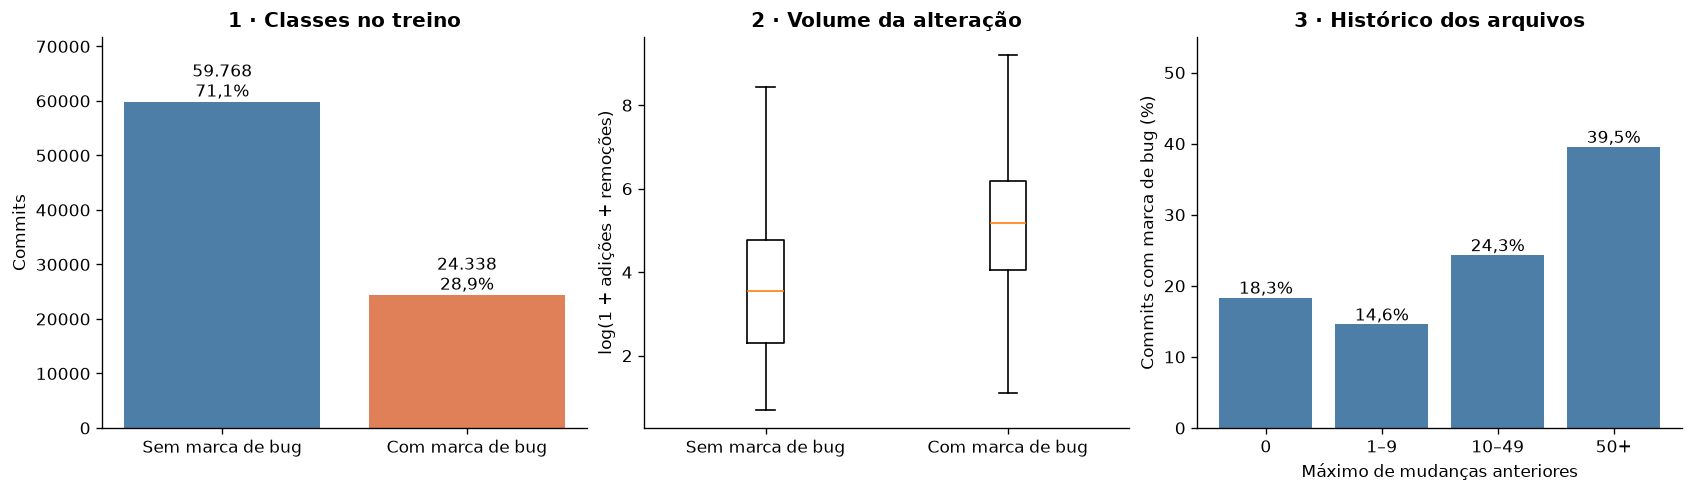

In [2]:
auditoria = json.loads((ROOT/'resultados/auditoria_treino.json').read_text(encoding='utf-8'))
display(pd.DataFrame({'tipo': auditoria['tipos'], 'valores ausentes': auditoria['ausencias']}))
display(treino[FEATURES].describe(percentiles=[.5, .95, .99]).T)
exclusoes = pd.read_csv(ROOT/'resultados/exclusoes.csv')
display(exclusoes.motivo.value_counts().rename('commits excluídos').to_frame())
print('Commits repetidos no treino:', auditoria['duplicatas_sha'])
print('Dimensões: treino', treino[FEATURES].shape, '| avaliação principal', teste[FEATURES].shape,
      '| análise de 2019', teste_2019[FEATURES].shape)
print('Cobertura da extração em todos os períodos:', pct((len(treino) + len(teste_completo)) / len(original), 2))
assert treino[FEATURES].isna().sum().sum() == 0 and treino.commit_id.is_unique
display(graficos.explorar(treino)); plt.close('all')

**Leitura dos três gráficos acima**

1. **Classes.** Só 28,9% dos commits de treino têm marca de bug. Por isso acertar "no geral" é fácil e enganoso.
2. **Tamanho.** Commits com bug são maiores: metade deles altera mais de 175 linhas, contra 34 nos demais. Mas há muita mistura; tamanho sozinho não separa os dois grupos.
3. **Histórico do arquivo.** Quando o commit mexe em um arquivo que já foi alterado 50 vezes ou mais, 39,5% têm marca de bug. Em arquivos alterados de 1 a 9 vezes, 14,6%.

Os dois gráficos abaixo mostram o mesmo tipo de relação para outras duas características. Em todos os casos é uma
**associação**: arquivos muito alterados costumam ser os mais centrais e complexos. Os gráficos não provam
que alterar um arquivo cause bugs.

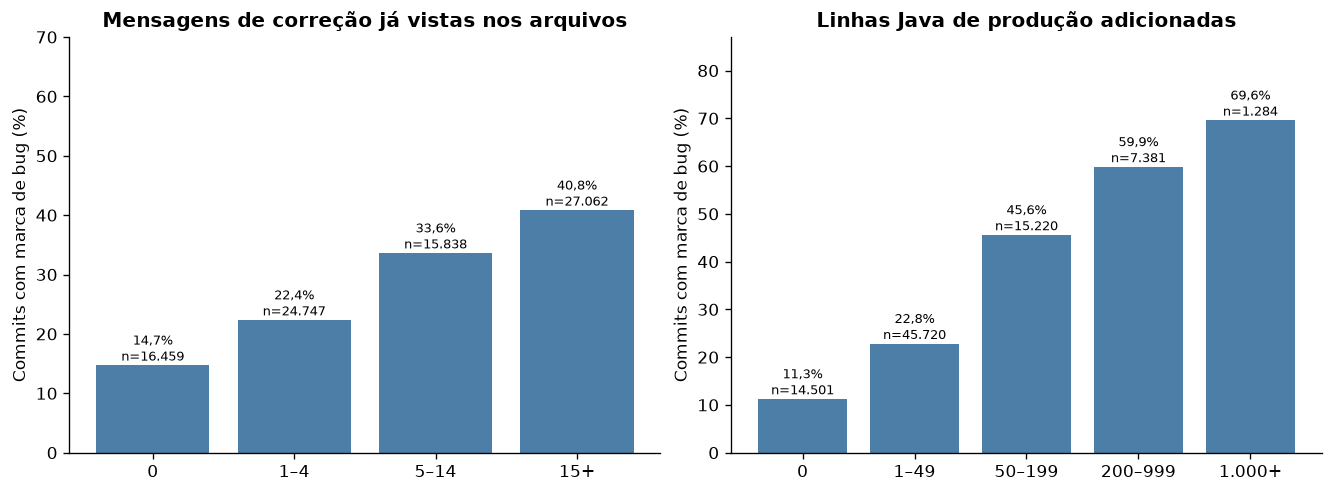

In [3]:
taxa = treino.buggy.mean()
medianas = (treino.la + treino.ld).groupby(treino.buggy).median()
mudancas = graficos.taxas(treino, 'l_arq_mudancas_max', [-1, 0, 9, 49, np.inf], ['0', '1–9', '10–49', '50+'])
texto(f'''**Leitura dos três gráficos acima**

1. **Classes.** Só {pct(taxa)} dos commits de treino têm marca de bug. Por isso acertar "no geral" é fácil e enganoso.
2. **Tamanho.** Commits com bug são maiores: metade deles altera mais de {medianas[1]:.0f} linhas, contra {medianas[0]:.0f} nos demais. Mas há muita mistura; tamanho sozinho não separa os dois grupos.
3. **Histórico do arquivo.** Quando o commit mexe em um arquivo que já foi alterado 50 vezes ou mais, {pct(mudancas.loc['50+', 'taxa'])} têm marca de bug. Em arquivos alterados de 1 a 9 vezes, {pct(mudancas.loc['1–9', 'taxa'])}.

Os dois gráficos abaixo mostram o mesmo tipo de relação para outras duas características. Em todos os casos é uma
**associação**: arquivos muito alterados costumam ser os mais centrais e complexos. Os gráficos não provam
que alterar um arquivo cause bugs.''')
display(graficos.historico(treino)); plt.close('all')

### De onde vêm os rótulos e até onde podemos confiar neles?

Reproduzimos os filtros dos autores usando o pacote original do ApacheJIT e conferimos as ligações
entre relatos de bugs e correções no Git. Todas as marcas publicadas foram reproduzidas. Isso mostra
consistência com o método de coleta; não confirma que cada marca corresponda a um defeito real.

**Uma correção na leitura dos dados.** Muitos negativos do Hadoop usam o nome do repositório
`apache/hadoop`, enquanto positivos aparecem como `apache/hadoop-hdfs` ou `apache/hadoop-mapreduce`.
Comparar esses nomes isoladamente dá a impressão de que Hadoop não tem bugs. Nos diagnósticos,
usamos uma família Hadoop, mantendo todos os commits e suas marcas.

**Casos para revisão.** Algumas ligações confundem números de PR com números de bug, têm datas
incompatíveis ou apontam para relatos sem resolução “Fixed”. Uma flag não prova que o commit seja
limpo: ele pode ter outras correções associadas. A fila guarda também essas evidências alternativas.
Essa auditoria foi feita após os experimentos e não alterou o treino nem as previsões.
O método e as evidências estão em [AUDITORIA_ROTULOS.md](AUDITORIA_ROTULOS.md).

In [4]:
rotulos = carregar_auditoria()  # Confere os hashes da base, do modelo e dos resultados persistidos.
display(pd.Series({
    'Commits com rótulo reproduzido': mil(rotulos['linhas']),
    'Divergências em buggy': rotulos['rotulos_divergentes'],
    'Positivos com algum vínculo a revisar (todos no treino)': rotulos['positivos_para_revisao'],
    'Positivos sem nenhum relato Fixed associado': rotulos['positivos_sem_relato_fixed'],
    'Positivos cujos vínculos não citam a chave do bug': rotulos['positivos_so_vinculos_sem_chave'],
    'Rótulos alterados pela auditoria': rotulos['rotulos_alterados'],
}).to_frame('Resultado da auditoria'))
grupos_fonte = pd.read_csv(PASTA_AUDITORIA/'grupos_fonte.csv')
hadoop = grupos_fonte[grupos_fonte.project.str.startswith('apache/hadoop')]
display(hadoop.rename(columns={'project': 'Nome na fonte', 'taxa_buggy': 'Fração com marca de bug'}).round(4))
h = rotulos['familia_hadoop']
texto(f"**Leitura:** reunidos, são {mil(h['commits'])} commits e {mil(h['positivos'])} positivos "
      f"({pct(h['taxa_buggy'])}). A família é usada apenas nos relatórios, nunca como entrada do modelo. "
      "Pesos de classe equilibram a contribuição das marcas disponíveis, mas não corrigem sua origem.")

,Resultado da auditoria
Commits com rótulo reproduzido,106.674
Divergências em buggy,0
Positivos com algum vínculo a revisar (todos no treino),64
Positivos sem nenhum relato Fixed associado,11
Positivos cujos vínculos não citam a chave do bug,1
Rótulos alterados pela auditoria,0


,Nome na fonte,commits,positivos,Fração com marca de bug
5,apache/hadoop,11964,0,0.0000
6,apache/hadoop-hdfs,2907,2222,0.7644
7,apache/hadoop-mapreduce,1321,838,0.6344


**Leitura:** reunidos, são 16.192 commits e 3.060 positivos (18,9%). A família é usada apenas nos relatórios, nunca como entrada do modelo. Pesos de classe equilibram a contribuição das marcas disponíveis, mas não corrigem sua origem.

## Exercício 3 — Variáveis e desenho do experimento

Definimos as entradas do modelo, os cuidados contra vazamento de informação e a sequência de avaliação.

### O que o modelo vê (`X`): 48 pistas em seis grupos

| Grupo | Exemplos de pistas |
|---|---|
| Tamanho | linhas adicionadas, linhas removidas, arquivos alterados |
| Tipo da alteração | quantos arquivos são de teste, quantas linhas estão em código de produção |
| Momento | hora e dia da semana em que o commit foi escrito |
| Mensagem | tamanho da mensagem do commit |
| Autor | quantos commits a pessoa já tinha feito, se já tinha mexido nesses arquivos |
| Histórico dos arquivos | quantas vezes já foram alterados, por quantas pessoas, quantas mensagens antigas falavam em correção |

A lista completa aparece na tabela abaixo e em `esquema.py`. O alvo `y` é `buggy`.

### O que o modelo não vê, para evitar vazamento

Vazamento é dar ao modelo uma informação que entrega a resposta, ou que ele não teria na vida real.

- **Identificadores** (SHA, e-mail, nome do projeto). Não descrevem a alteração. Nesta base, o nome do projeto ainda está ligado ao modo como os commits com bug foram coletados.
- **Colunas `buggy` e `fix` de outros commits.** São respostas, não pistas.
- **Informações futuras como entradas (`X`).** O histórico de um commit conta apenas o que veio **antes** dele na linha principal do repositório. Commits posteriores e de outras branches não entram. Há testes automáticos só para isso em `testar_extracao.py`. A disponibilidade histórica do alvo `y` tem uma limitação diferente, descrita abaixo.
- **Palavras da mensagem do próprio commit**, como "fix". Ficaram de fora por cautela, porque a base foi montada a partir de correções. Testamos à parte e quase não muda o resultado (Exercício 5).

Um detalhe de vocabulário: "correções anteriores" de um arquivo significa mensagens antigas com palavras como
*fix* ou *bug*. É um indício de que o arquivo já deu trabalho, não um bug confirmado.

### Como o modelo é testado

- **Treino:** 84.106 commits com integração anterior a 06/10/2017 às 17:39:59 UTC.
- **Avaliação principal:** 11.292 commits entre esse corte e 31/12/2018.
- **Análise complementar:** 10.441 commits de 2019, separados da avaliação principal.
- **Ordem temporal:** não sorteamos nem estratificamos. Uma divisão aleatória poderia usar informação futura para avaliar commits antigos. A semente 42 controla a aleatoriedade dos estimadores.
- **Validação cruzada temporal, com 3 folds.** Dentro do treino fazemos três comparações cronológicas. Em cada uma, o modelo aprende com commits mais antigos e é avaliado no trecho seguinte. O trecho de aprendizado cresce a cada rodada. Os rótulos são retrospectivos, portanto isso não reproduz exatamente os dados disponíveis em cada data.
- **Mesmas condições para todos.** Os três algoritmos usam as mesmas pistas, os mesmos três simulados e a mesma métrica. A semente aleatória é 42 em tudo, para o resultado ser reproduzível.

**Por que separar 2019?** Os rótulos foram obtidos a partir de correções posteriores aos commits.
Os commits mais recentes podem ter menos tempo para que seus bugs sejam identificados. Isso motiva uma
análise separada, mas não demonstra que os rótulos de 2019 estejam incorretos. A fronteira do treino é
mantida, e as duas regras de alerta são comparadas nos mesmos registros. Excluir um período da avaliação
não representa, por si só, uma melhora do modelo.

**Etapas da seleção.** Primeiro comparamos os três algoritmos e suas buscas com limiar 0,50.
Depois, no LightGBM selecionado, comparamos pesos iguais ou balanceados e limiar fixo ou ajustado.
Para ajustar o limiar de cada fold, usamos uma divisão temporal interna de 80%/20% do seu treino;
só então medimos o resultado na validação externa. Validação e teste mantêm suas proporções reais de classes.

**Limite metodológico.** O período de avaliação já havia sido consultado durante o desenvolvimento, antes
da decisão de separar 2019. Portanto, o resultado é uma reavaliação exploratória de dados conhecidos,
com risco de adaptação indireta. Os rótulos desse período não entram nas funções de busca ou ajuste de limiar,
mas isso não o transforma em teste inédito. Os protocolos e registros completos estão em
`PROTOCOLO.md` e `PROTOCOLO_REVISAO.md`.

**Quando a marca de bug ficou disponível?** Um commit de 2016 pode ter recebido sua marca apenas
por uma correção de 2018. A auditoria compara a primeira correção vinculada no pacote com o fim
de cada treino. As entradas são históricas, mas parte dos alvos depende de correções posteriores
ao corte. Assim, as métricas medem uma classificação retrospectiva, não uma simulação estrita
de implantação. Uma nova avaliação precisaria respeitar também a disponibilidade dos rótulos e
dar tempo de observação consistente aos commits. Remover apenas os positivos descobertos depois
ou tratá-los como negativos introduziria outro viés.

### Métricas

| Métrica | O que responde |
|---|---|
| **F1 da classe 1 (principal)** | Média harmônica de precision e recall; avalia a regra de alerta |
| Precision | Dos alertas, quantos eram bugs |
| Recall | Dos bugs, quantos foram alertados |
| Acurácia | Quantas respostas certas no total; engana quando bug é raro |
| Acurácia balanceada | Média da sensibilidade para cada classe; dá o mesmo peso às duas classes |
| ROC-AUC | Sorteando um commit com bug e um sem, quantas vezes o com bug recebe o score maior (0,5 é sorte, 1 é perfeito) |
| Average Precision | Qualidade da ordenação, olhando para os commits com bug |

In [5]:
display(pd.DataFrame([{'grupo': g, 'variável': f, 'significado': d} for g, fs in GRUPOS.items() for f, d in fs.items()]))
display(pd.read_csv(ROOT/'resultados/folds.csv'))
assert len(FEATURES) == 48
assert not set(treino.commit_id) & set(teste.commit_id)
assert not set(treino.commit_id) & set(teste_2019.commit_id)
assert teste.data.max() < pd.Timestamp('2019-01-01', tz='UTC') <= teste_2019.data.min()
assert len(treino) + len(teste) + len(teste_2019) + divisao['n_excluidos'] == len(original)
for it, iv in folds:
    assert treino.iloc[it].data.max() < treino.iloc[iv].data.min()
print('Conferido: nenhum commit está no treino e no período final, e cada simulado avalia só datas posteriores ao seu treino.')
texto('**Código da separação dos períodos de avaliação**; a divisão inicial e a extração estão em `dados.py`:')
mostrar_codigo(separar_periodos)

,grupo,variável,significado
0,Tamanho,la,Linhas adicionadas
1,Tamanho,ld,Linhas removidas
2,Tamanho,nf,Arquivos afetados
3,Tipo da alteração,o_n_java,Arquivos Java
4,Tipo da alteração,o_n_teste,Arquivos de teste
5,Tipo da alteração,o_n_producao,Arquivos Java fora de testes
6,Tipo da alteração,o_n_outros,Arquivos não Java
7,Tipo da alteração,o_tem_teste,Presença de teste
8,Tipo da alteração,o_frac_la_teste,Fração das adições em testes
9,Tipo da alteração,o_la_producao,Adições em Java de produção


,fold,n_treino,n_validacao,treino_inicio,treino_fim,validacao_inicio,validacao_fim
0,1,20166,20463,2003-09-11 14:54:46+00:00,2011-03-21 23:56:35+00:00,2011-03-22 00:22:04+00:00,2014-02-21 10:56:47+00:00
1,2,40629,21678,2003-09-11 14:54:46+00:00,2014-02-21 10:56:47+00:00,2014-02-21 11:26:01+00:00,2015-09-10 07:34:24+00:00
2,3,62307,21799,2003-09-11 14:54:46+00:00,2015-09-10 07:34:24+00:00,2015-09-10 07:42:01+00:00,2017-10-06 17:12:24+00:00


Conferido: nenhum commit está no treino e no período final, e cada simulado avalia só datas posteriores ao seu treino.


**Código da separação dos períodos de avaliação**; a divisão inicial e a extração estão em `dados.py`:

```python
def separar_periodos(teste):
    principal = teste[teste.data < FIM_PRINCIPAL].reset_index(drop=True)
    sensibilidade = teste[teste.data >= FIM_PRINCIPAL].reset_index(drop=True)
    if principal.empty or sensibilidade.empty:
        raise ValueError("Esperados holdout até 2018 e período de sensibilidade 2019+.")
    return principal, sensibilidade
```

In [6]:
disponibilidade = pd.read_csv(PASTA_AUDITORIA/'disponibilidade_temporal.csv')
display(disponibilidade[['trecho', 'fim_treino', 'positivos_treino',
                         'primeira_correcao_posterior', 'fracao_dos_positivos']].round(4))
d = disponibilidade.set_index('trecho').loc['treino_final']
texto(f"**Leitura:** {mil(d.primeira_correcao_posterior)} dos {mil(d.positivos_treino)} positivos "
      f"do treino ({pct(d.fracao_dos_positivos)}) têm sua primeira correção vinculada depois do corte. "
      "A limitação é ainda maior nas primeiras janelas. A data é da evidência registrada no pacote; "
      "ela não garante que ninguém conhecesse o defeito antes. Essas datas não entram no modelo.")

,trecho,fim_treino,positivos_treino,primeira_correcao_posterior,fracao_dos_positivos
0,treino_final,2017-10-06 17:12:24+00:00,24338,3099,0.1273
1,fold_1,2011-03-21 23:56:35+00:00,4965,2618,0.5273
2,fold_2,2014-02-21 10:56:47+00:00,12036,3322,0.2760
3,fold_3,2015-09-10 07:34:24+00:00,17998,4163,0.2313


**Leitura:** 3.099 dos 24.338 positivos do treino (12,7%) têm sua primeira correção vinculada depois do corte. A limitação é ainda maior nas primeiras janelas. A data é da evidência registrada no pacote; ela não garante que ninguém conhecesse o defeito antes. Essas datas não entram no modelo.

## Exercício 4 — Três modelos de referência

Treinamos os três algoritmos com configurações de referência, antes da busca de hiperparâmetros.
Todos começam com 150 árvores, semente 42 e dois núcleos. Os demais parâmetros aparecem abaixo.

Os três são feitos de **árvores de decisão**. Uma árvore é uma sequência de perguntas de sim ou não
("mais de 100 linhas?", "o arquivo já foi alterado mais de 50 vezes?") que termina em um risco.

- **Random Forest:** muitas árvores independentes, cada uma dá um palpite e elas votam.
- **XGBoost e LightGBM:** as árvores são construídas uma depois da outra, e cada nova árvore tenta corrigir os erros das anteriores (*boosting*).

Para comparação, incluímos duas regras simples: o **Dummy**, que sempre responde "sem bug", e o
**Sempre positivo**, que alerta tudo. Um modelo útil precisa ser melhor que os dois.

Na tabela, "F1 treino" é a nota nos dados que o modelo estudou e "F1 validação" é a nota nos simulados.
"Gap" é a diferença entre as duas; "desvio" é o quanto a nota variou entre os três simulados.

In [7]:
texto('**Código que monta cada modelo, calcula as métricas e roda os três simulados** (`treinamento.py`):')
mostrar_codigo(construir, metricas, avaliar_cv)

**Código que monta cada modelo, calcula as métricas e roda os três simulados** (`treinamento.py`):

```python
def construir(nome, parametros=None):
    comuns = {"random_state": SEED, "n_jobs": N_JOBS, "n_estimators": 150}
    if nome == "Random Forest":
        params = {**comuns, "max_depth": None, "min_samples_leaf": 1, **(parametros or {})}
        modelo = RandomForestClassifier(**params)
    elif nome == "XGBoost":
        params = {**comuns, "max_depth": 6, "learning_rate": 0.1, "tree_method": "hist",
                  "objective": "binary:logistic", "eval_metric": "logloss", **(parametros or {})}
        modelo = XGBClassifier(**params)
    elif nome == "LightGBM":
        params = {**comuns, "num_leaves": 31, "learning_rate": 0.1, "verbosity": -1,
                  "deterministic": True, "force_col_wise": True, **(parametros or {})}
        modelo = LGBMClassifier(**params)
    elif nome == "Sempre positivo":
        modelo = DummyClassifier(strategy="constant", constant=1, random_state=SEED)
    else:
        modelo = DummyClassifier(strategy="most_frequent", random_state=SEED)
    imputer = SimpleImputer(strategy="median", keep_empty_features=True).set_output(transform="pandas")
    return Pipeline([("imputacao", imputer), ("modelo", modelo)])
```

```python
def metricas(y, p):
    pred = (np.asarray(p) >= LIMIAR).astype(int)
    return {"f1": f1_score(y, pred, zero_division=0),
            "precision": precision_score(y, pred, zero_division=0),
            "recall": recall_score(y, pred, zero_division=0),
            "acuracia": accuracy_score(y, pred), "roc_auc": roc_auc_score(y, p),
            "average_precision": average_precision_score(y, p)}
```

```python
def avaliar_cv(nome, params, treino, folds):
    inicio = perf_counter()
    scores = cross_validate(construir(nome, params), treino[FEATURES], treino.buggy,
                            cv=folds, scoring=pontuar, n_jobs=1, return_train_score=True,
                            error_score="raise")
    return scores, perf_counter() - inicio
```

In [8]:
base = pd.DataFrame(baselines(treino, folds))
colunas = ['modelo', 'estrategia', 'f1_treino', 'f1_validacao', 'desvio_f1', 'gap',
           'validacao_precision', 'validacao_recall', 'validacao_acuracia', 'validacao_roc_auc', 'tempo_s']
display(base[colunas].round(4))
display(pd.DataFrame([{'modelo': r['modelo'], 'hiperparâmetros': r['hiperparametros_completos']} for r in base.to_dict('records')]))
linha = base.set_index('modelo')
rf, xgb, lgbm, dummy, sempre = (linha.loc[n] for n in ['Random Forest', 'XGBoost', 'LightGBM', 'Dummy', 'Sempre positivo'])
texto(f'''**Leitura**

- **Os três aprendem alguma coisa.** F1 de validação: Random Forest {br(rf.f1_validacao)}, XGBoost {br(xgb.f1_validacao)}, LightGBM {br(lgbm.f1_validacao)}. O Dummy tem F1 {br(dummy.f1_validacao)} e alertar tudo dá {br(sempre.f1_validacao)}.
- **Sinal de sobreajuste (overfitting).** O Random Forest tira {br(rf.f1_treino)} no treino e {br(rf.f1_validacao)} na validação: ele decorou os dados de treino. XGBoost e LightGBM também vão melhor no treino (gaps de {br(xgb.gap)} e {br(lgbm.gap)}), em grau menor.
- **Por que não olhar só a acurácia.** O Dummy acerta {pct(dummy.validacao_acuracia)} das respostas sem encontrar nenhum bug. Os modelos chegam a cerca de {pct(lgbm.validacao_acuracia)}.
- **Custo.** O Random Forest levou {br(rf.tempo_s, 1)} s nos três simulados; XGBoost e LightGBM, {br(xgb.tempo_s, 1)} s e {br(lgbm.tempo_s, 1)} s.''')

,modelo,estrategia,f1_treino,f1_validacao,desvio_f1,gap,validacao_precision,validacao_recall,validacao_acuracia,validacao_roc_auc,tempo_s
0,Random Forest,Baseline,1.0000,0.5536,0.0485,0.4464,0.6464,0.4958,0.7623,0.7881,18.0155
1,XGBoost,Baseline,0.7337,0.5371,0.0657,0.1967,0.6490,0.4839,0.7574,0.7927,2.9026
2,LightGBM,Baseline,0.7223,0.5472,0.0587,0.1751,0.6491,0.4952,0.7600,0.7933,2.7195
3,Dummy,Baseline,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.6962,0.5000,0.4922
4,Sempre positivo,Baseline,0.4335,0.4652,0.0351,-0.0317,0.3038,1.0000,0.3038,0.5000,0.4825


,modelo,hiperparâmetros
0,Random Forest,"{'bootstrap': True, 'ccp_alpha': 0.0, 'class_weight': None, 'criterion': 'gini', 'max_depth': No..."
1,XGBoost,"{'objective': 'binary:logistic', 'base_score': None, 'booster': None, 'callbacks': None, 'colsam..."
2,LightGBM,"{'boosting_type': 'gbdt', 'class_weight': None, 'colsample_bytree': 1.0, 'importance_type': 'spl..."
3,Dummy,"{'constant': None, 'random_state': 42, 'strategy': 'most_frequent'}"
4,Sempre positivo,"{'constant': 1, 'random_state': 42, 'strategy': 'constant'}"


**Leitura**

- **Os três aprendem alguma coisa.** F1 de validação: Random Forest 0,554, XGBoost 0,537, LightGBM 0,547. O Dummy tem F1 0,000 e alertar tudo dá 0,465.
- **Sinal de sobreajuste (overfitting).** O Random Forest tira 1,000 no treino e 0,554 na validação: ele decorou os dados de treino. XGBoost e LightGBM também vão melhor no treino (gaps de 0,197 e 0,175), em grau menor.
- **Por que não olhar só a acurácia.** O Dummy acerta 69,6% das respostas sem encontrar nenhum bug. Os modelos chegam a cerca de 76,0%.
- **Custo.** O Random Forest levou 18,0 s nos três simulados; XGBoost e LightGBM, 2,9 s e 2,7 s.

## Exercício 5 — Ajuste com Grid Search e Optuna

**Em poucas palavras:** cada modelo tem "botões" (hiperparâmetros), como o número de árvores e a profundidade delas.
Testamos duas formas de escolher esses botões, sempre usando só os três simulados do treino.

**Grid Search** testa todas as combinações de um cardápio fixo. Aqui são 8 combinações por modelo:

| Modelo | Cardápio |
|---|---|
| Random Forest | árvores 150 ou 300; profundidade 8 ou sem limite; mínimo de commits por folha 1 ou 5 |
| XGBoost | árvores 150 ou 300; profundidade 3 ou 6; taxa de aprendizado 0,05 ou 0,1 |
| LightGBM | árvores 150 ou 300; folhas 15 ou 31; taxa de aprendizado 0,05 ou 0,1 |

**Optuna** não segue um cardápio. Ele testa uma configuração, olha a nota e usa isso para escolher a próxima.
Foram **20 tentativas (trials) por modelo**, com semente 42:

| Modelo | Onde o Optuna pode procurar |
|---|---|
| Todos | árvores de 150 a 300, de 50 em 50 |
| Random Forest | profundidade 8, 16 ou sem limite; mínimo por folha de 1 a 10; pistas por divisão: raiz quadrada ou todas |
| XGBoost | taxa de 0,03 a 0,2; profundidade de 2 a 6; `min_child_weight` de 1 a 10 |
| LightGBM | taxa de 0,03 a 0,2; folhas de 15 a 63; `min_child_samples` de 10 a 60 |

Nos dois casos, o objetivo é o maior F1 médio nos três simulados. O período final não participa.
Os tempos mostrados são os da execução original, não os de leitura dos resultados salvos.

In [9]:
print('Cardápios do Grid Search:', json.dumps(GRADES, ensure_ascii=False))
texto('**Código das duas buscas** (`treinamento.py`):')
mostrar_codigo(buscar_grid, sugerir, buscar_optuna)

Cardápios do Grid Search: {"Random Forest": {"n_estimators": [150, 300], "max_depth": [8, null], "min_samples_leaf": [1, 5]}, "XGBoost": {"n_estimators": [150, 300], "max_depth": [3, 6], "learning_rate": [0.05, 0.1]}, "LightGBM": {"n_estimators": [150, 300], "num_leaves": [15, 31], "learning_rate": [0.05, 0.1]}}


**Código das duas buscas** (`treinamento.py`):

```python
def buscar_grid(nome, treino, folds):
    path = RESULTADOS / f"grid_{slug(nome)}.json"
    if path.exists():
        return json.loads(path.read_text(encoding="utf-8"))
    print("Grid Search:", nome, "(8 combinações x 3 folds)", flush=True)
    busca = GridSearchCV(construir(nome), {f"modelo__{k}": v for k, v in GRADES[nome].items()},
                         scoring=pontuar, refit=False, cv=folds, n_jobs=1,
                         return_train_score=True, error_score="raise")
    inicio = perf_counter()
    busca.fit(treino[FEATURES], treino.buggy)
    tempo = perf_counter() - inicio
    tabela = pd.DataFrame(busca.cv_results_)
    tabela.to_csv(RESULTADOS / f"grid_{slug(nome)}_candidatos.csv", index=False)
    joblib.dump(busca.cv_results_, RESULTADOS / f"grid_{slug(nome)}_cv.joblib")
    melhor = int(tabela.mean_test_f1.argmax())
    params = {k.removeprefix("modelo__"): v for k, v in busca.cv_results_["params"][melhor].items()}
    scores = {f"{lado}_{metrica}": np.array([busca.cv_results_[f"split{k}_{lado}_{metrica}"][melhor]
               for k in range(3)]) for lado in ["train", "test"]
               for metrica in ["f1", "precision", "recall", "acuracia", "roc_auc", "average_precision"]}
    scores["fit_time"] = np.array([busca.cv_results_["mean_fit_time"][melhor]])
    linha = resumo_cv(nome, "Grid Search", params, scores, tempo)
    salvar_json(path, linha)
    return linha
```

```python
def sugerir(trial, nome):
    params = {"n_estimators": trial.suggest_int("n_estimators", 150, 300, step=50)}
    if nome == "Random Forest":
        params.update(max_depth=trial.suggest_categorical("max_depth", [8, 16, None]),
                      min_samples_leaf=trial.suggest_int("min_samples_leaf", 1, 10),
                      max_features=trial.suggest_categorical("max_features", ["sqrt", 1.0]))
    else:
        params["learning_rate"] = trial.suggest_float("learning_rate", 0.03, 0.2, log=True)
        if nome == "XGBoost":
            params.update(max_depth=trial.suggest_int("max_depth", 2, 6),
                          min_child_weight=trial.suggest_int("min_child_weight", 1, 10))
        else:
            params.update(num_leaves=trial.suggest_int("num_leaves", 15, 63),
                          min_child_samples=trial.suggest_int("min_child_samples", 10, 60))
    return params
```

```python
def buscar_optuna(nome, treino, folds):
    path = RESULTADOS / f"optuna_{slug(nome)}.json"
    if path.exists():
        return json.loads(path.read_text(encoding="utf-8"))
    optuna.logging.set_verbosity(optuna.logging.WARNING)
    sampler_path = RESULTADOS / f"sampler_{slug(nome)}.joblib"
    sampler = joblib.load(sampler_path) if sampler_path.exists() else optuna.samplers.TPESampler(seed=SEED)
    estudo = optuna.create_study(study_name=slug(nome), direction="maximize", sampler=sampler,
                                 storage=f"sqlite:///{(RESULTADOS / 'optuna.sqlite3').as_posix()}",
                                 load_if_exists=True)
    # Trials interrompidos não contam para os 20 completos.
    for t in estudo.get_trials(deepcopy=False):
        if t.state == optuna.trial.TrialState.RUNNING:
            estudo.tell(t.number, state=optuna.trial.TrialState.FAIL)
    def objetivo(trial):
        params = sugerir(trial, nome)
        scores, tempo = avaliar_cv(nome, params, treino, folds)
        linha = resumo_cv(nome, "Optuna", params, scores, tempo)
        trial.set_user_attr("resultado", linha)
        return linha["f1_validacao"]
    def checkpoint(study, trial):
        joblib.dump(study.sampler, sampler_path)
        study.trials_dataframe().to_csv(RESULTADOS / f"optuna_{slug(nome)}_trials.csv", index=False)
        print(f"Optuna {nome}: trial {trial.number + 1}/20, F1={trial.value:.4f}", flush=True)
    completos = sum(t.state == optuna.trial.TrialState.COMPLETE for t in estudo.trials)
    estudo.optimize(objetivo, n_trials=max(0, 20 - completos), n_jobs=1, callbacks=[checkpoint])
    linha = dict(estudo.best_trial.user_attrs["resultado"])
    linha["tempo_melhor_trial_s"] = linha["tempo_s"]
    linha["tempo_s"] = sum(t.duration.total_seconds() for t in estudo.trials if t.duration)
    linha["trials_completos"] = sum(t.state == optuna.trial.TrialState.COMPLETE for t in estudo.trials)
    salvar_json(path, linha)
    return linha
```

**Random Forest — as 8 combinações do Grid Search e as 20 tentativas do Optuna**

,params,mean_test_f1,std_test_f1,mean_train_f1,mean_fit_time
4,"{'modelo__max_depth': None, 'modelo__min_samples_leaf': 1, 'modelo__n_estimators': 150}",0.553640,0.048513,1.000000,6.027939
5,"{'modelo__max_depth': None, 'modelo__min_samples_leaf': 1, 'modelo__n_estimators': 300}",0.551101,0.049562,1.000000,11.702702
7,"{'modelo__max_depth': None, 'modelo__min_samples_leaf': 5, 'modelo__n_estimators': 300}",0.550412,0.045811,0.842296,10.465465
6,"{'modelo__max_depth': None, 'modelo__min_samples_leaf': 5, 'modelo__n_estimators': 150}",0.550243,0.047428,0.841967,5.059278
3,"{'modelo__max_depth': 8, 'modelo__min_samples_leaf': 5, 'modelo__n_estimators': 300}",0.519633,0.046309,0.575644,6.098194
2,"{'modelo__max_depth': 8, 'modelo__min_samples_leaf': 5, 'modelo__n_estimators': 150}",0.518119,0.046874,0.573888,2.922681
1,"{'modelo__max_depth': 8, 'modelo__min_samples_leaf': 1, 'modelo__n_estimators': 300}",0.517709,0.047705,0.580888,5.741971
0,"{'modelo__max_depth': 8, 'modelo__min_samples_leaf': 1, 'modelo__n_estimators': 150}",0.512992,0.049063,0.579489,2.957781


,number,value,params_max_depth,params_max_features,params_min_samples_leaf,params_n_estimators,state
0,0,0.518594,8.0,sqrt,2,200,COMPLETE
1,1,0.545990,16.0,sqrt,10,300,COMPLETE
2,2,0.538601,NaN,1.0,5,150,COMPLETE
3,3,0.537040,NaN,1.0,8,150,COMPLETE
4,4,0.538877,16.0,1.0,1,250,COMPLETE
5,5,0.538839,NaN,1.0,5,300,COMPLETE
6,6,0.520774,8.0,1.0,4,150,COMPLETE
7,7,0.522150,8.0,1.0,9,150,COMPLETE
8,8,0.537498,NaN,1.0,4,150,COMPLETE
9,9,0.538293,16.0,1.0,9,200,COMPLETE


**XGBoost — as 8 combinações do Grid Search e as 20 tentativas do Optuna**

,params,mean_test_f1,std_test_f1,mean_train_f1,mean_fit_time
7,"{'modelo__learning_rate': 0.1, 'modelo__max_depth': 6, 'modelo__n_estimators': 300}",0.545841,0.062861,0.816189,1.380401
3,"{'modelo__learning_rate': 0.05, 'modelo__max_depth': 6, 'modelo__n_estimators': 300}",0.543754,0.065741,0.733941,1.422236
5,"{'modelo__learning_rate': 0.1, 'modelo__max_depth': 3, 'modelo__n_estimators': 300}",0.538383,0.067387,0.640190,0.687114
6,"{'modelo__learning_rate': 0.1, 'modelo__max_depth': 6, 'modelo__n_estimators': 150}",0.537063,0.065737,0.733720,0.817932
2,"{'modelo__learning_rate': 0.05, 'modelo__max_depth': 6, 'modelo__n_estimators': 150}",0.533686,0.065955,0.672826,0.858251
4,"{'modelo__learning_rate': 0.1, 'modelo__max_depth': 3, 'modelo__n_estimators': 150}",0.527945,0.069749,0.610759,0.465567
1,"{'modelo__learning_rate': 0.05, 'modelo__max_depth': 3, 'modelo__n_estimators': 300}",0.525807,0.071698,0.607524,0.699073
0,"{'modelo__learning_rate': 0.05, 'modelo__max_depth': 3, 'modelo__n_estimators': 150}",0.505968,0.072154,0.580904,0.465017


,number,value,params_learning_rate,params_max_depth,params_min_child_weight,params_n_estimators,state
0,0,0.551363,0.182147,5,6,200,COMPLETE
1,1,0.484963,0.040332,2,9,150,COMPLETE
2,2,0.530795,0.114950,2,10,250,COMPLETE
3,3,0.505041,0.044882,2,2,300,COMPLETE
4,4,0.537700,0.081184,4,3,200,COMPLETE
5,5,0.511256,0.039089,3,4,250,COMPLETE
6,6,0.532164,0.133056,2,6,200,COMPLETE
7,7,0.534431,0.032764,5,2,250,COMPLETE
8,8,0.547636,0.181517,6,9,150,COMPLETE
9,9,0.528568,0.036107,5,5,200,COMPLETE


**LightGBM — as 8 combinações do Grid Search e as 20 tentativas do Optuna**

,params,mean_test_f1,std_test_f1,mean_train_f1,mean_fit_time
3,"{'modelo__learning_rate': 0.05, 'modelo__n_estimators': 300, 'modelo__num_leaves': 31}",0.552632,0.057524,0.723143,1.057854
7,"{'modelo__learning_rate': 0.1, 'modelo__n_estimators': 300, 'modelo__num_leaves': 31}",0.549268,0.057732,0.804179,0.949908
6,"{'modelo__learning_rate': 0.1, 'modelo__n_estimators': 300, 'modelo__num_leaves': 15}",0.548986,0.058373,0.711495,0.799900
5,"{'modelo__learning_rate': 0.1, 'modelo__n_estimators': 150, 'modelo__num_leaves': 31}",0.547239,0.058699,0.722324,0.616554
1,"{'modelo__learning_rate': 0.05, 'modelo__n_estimators': 150, 'modelo__num_leaves': 31}",0.546790,0.059336,0.669526,0.716997
4,"{'modelo__learning_rate': 0.1, 'modelo__n_estimators': 150, 'modelo__num_leaves': 15}",0.545434,0.061117,0.660391,0.530515
2,"{'modelo__learning_rate': 0.05, 'modelo__n_estimators': 300, 'modelo__num_leaves': 15}",0.542035,0.062617,0.660862,0.867037
0,"{'modelo__learning_rate': 0.05, 'modelo__n_estimators': 150, 'modelo__num_leaves': 15}",0.535593,0.064781,0.626187,0.586218


,number,value,params_learning_rate,params_min_child_samples,params_n_estimators,params_num_leaves,state
0,0,0.552465,0.182147,40,200,50,COMPLETE
1,1,0.534423,0.040332,54,150,17,COMPLETE
2,2,0.555941,0.114950,59,250,16,COMPLETE
3,3,0.549979,0.044882,19,300,23,COMPLETE
4,4,0.553811,0.081184,24,200,36,COMPLETE
5,5,0.550027,0.039089,28,250,29,COMPLETE
6,6,0.555853,0.133056,36,200,24,COMPLETE
7,7,0.551431,0.032764,18,250,44,COMPLETE
8,8,0.544678,0.181517,51,150,62,COMPLETE
9,9,0.550167,0.036107,32,200,48,COMPLETE


,modelo,estrategia,parametros,f1_validacao,desvio_f1,tempo_s
3,Random Forest,Grid Search,"{'max_depth': None, 'min_samples_leaf': 1, 'n_estimators': 150}",0.5536,0.0485,168.9025
4,Random Forest,Optuna,"{'n_estimators': 300, 'max_depth': None, 'min_samples_leaf': 2, 'max_features': 'sqrt'}",0.5549,0.0476,1388.1760
5,XGBoost,Grid Search,"{'learning_rate': 0.1, 'max_depth': 6, 'n_estimators': 300}",0.5458,0.0629,23.3140
6,XGBoost,Optuna,"{'n_estimators': 200, 'learning_rate': 0.18214744423753768, 'max_depth': 5, 'min_child_weight': 6}",0.5514,0.0578,49.6072
7,LightGBM,Grid Search,"{'learning_rate': 0.05, 'n_estimators': 300, 'num_leaves': 31}",0.5526,0.0575,26.3139
8,LightGBM,Optuna,"{'n_estimators': 250, 'learning_rate': 0.07902978859187117, 'num_leaves': 27, 'min_child_samples...",0.5609,0.0515,73.3013


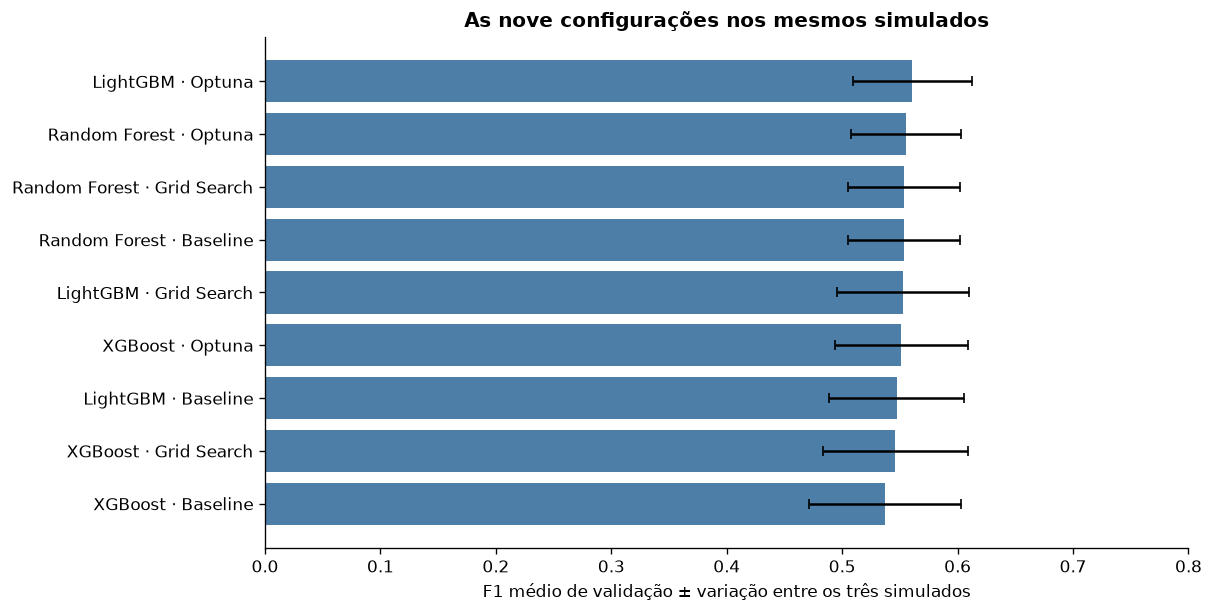

**Comparação das duas estratégias**

- **Random Forest:** Grid Search 0,5536 em 169 s; Optuna 0,5549 em 1388 s.
- **XGBoost:** Grid Search 0,5458 em 23 s; Optuna 0,5514 em 50 s.
- **LightGBM:** Grid Search 0,5526 em 26 s; Optuna 0,5609 em 73 s.

- **Qualidade.** O Optuna ficou à frente em 3 dos 3 modelos, mas por pouco: a maior diferença é de 0,0083 de F1. Isso é menor que a variação entre os três simulados, então não dá para dizer que uma estratégia é melhor que a outra.
- **Custo.** O Optuna demorou mais porque fez 20 tentativas contra 8 do Grid Search. No Random Forest a diferença de tempo é grande.
- **Comportamento.** O Grid Search só enxerga os valores do cardápio. O Optuna pode testar valores intermediários e se concentra nas regiões que deram nota melhor.
- **Cuidado.** Quanto mais tentativas, maior o risco de escolher uma configuração que só deu sorte nesses três simulados. Por isso existe um período final guardado.

In [10]:
tabela = comparacao(treino, folds)
for nome in MODELOS:
    texto(f'**{nome} — as 8 combinações do Grid Search e as 20 tentativas do Optuna**')
    grid = pd.read_csv(ROOT/f'resultados/grid_{slug(nome)}_candidatos.csv')
    display(grid[['params', 'mean_test_f1', 'std_test_f1', 'mean_train_f1', 'mean_fit_time']].sort_values('mean_test_f1', ascending=False))
    trials = pd.read_csv(ROOT/f'resultados/optuna_{slug(nome)}_trials.csv')
    assert trials.state.eq('COMPLETE').sum() == 20
    display(trials[[c for c in trials if c in ['number', 'value', 'state'] or c.startswith('params_')]])
buscas = tabela[tabela.estrategia.ne('Baseline')]
display(buscas[['modelo', 'estrategia', 'parametros', 'f1_validacao', 'desvio_f1', 'tempo_s']].round(4))
display(graficos.comparar(tabela)); plt.close('all')
frases = []
for nome in MODELOS:
    g = tabela[(tabela.modelo == nome) & (tabela.estrategia == 'Grid Search')].iloc[0]
    o = tabela[(tabela.modelo == nome) & (tabela.estrategia == 'Optuna')].iloc[0]
    frases.append(f'- **{nome}:** Grid Search {br(g.f1_validacao, 4)} em {br(g.tempo_s, 0)} s; Optuna {br(o.f1_validacao, 4)} em {br(o.tempo_s, 0)} s.')
diferencas = tabela[tabela.estrategia == 'Optuna'].f1_validacao.values - tabela[tabela.estrategia == 'Grid Search'].f1_validacao.values
ganho = diferencas.max()
texto('**Comparação das duas estratégias**\n\n' + '\n'.join(frases) + f'''

- **Qualidade.** O Optuna ficou à frente em {int((diferencas > 0).sum())} dos 3 modelos, mas por pouco: a maior diferença é de {br(ganho, 4)} de F1. Isso é menor que a variação entre os três simulados, então não dá para dizer que uma estratégia é melhor que a outra.
- **Custo.** O Optuna demorou mais porque fez 20 tentativas contra 8 do Grid Search. No Random Forest a diferença de tempo é grande.
- **Comportamento.** O Grid Search só enxerga os valores do cardápio. O Optuna pode testar valores intermediários e se concentra nas regiões que deram nota melhor.
- **Cuidado.** Quanto mais tentativas, maior o risco de escolher uma configuração que só deu sorte nesses três simulados. Por isso existe um período final guardado.''')

### Contribuição das características

Comparamos subconjuntos de características nos mesmos commits e folds.
A primeira linha é uma referência adicional com três entradas e hiperparâmetros próprios.
Para isolar a contribuição das características, a comparação controlada usa as quatro linhas seguintes,
todas com um XGBoost de configuração fixa.
A última linha acrescenta as palavras da mensagem do próprio commit, só para medir o efeito; elas não entram no modelo final.

In [11]:
pistas = comparar_entradas(treino, folds).copy()
pistas['estrategia'] = ['Só tamanho — referência adicional', 'Só tamanho — comparação controlada',
                       'Tamanho + tipo + mensagem', 'Características completas',
                       'Completas + palavras da mensagem atual']
display(pistas[['estrategia', 'n_entradas', 'f1_validacao', 'desvio_f1', 'validacao_precision', 'validacao_recall', 'validacao_acuracia', 'validacao_roc_auc']].round(4))
antigo, leve, completo, palavras = (pistas.iloc[i] for i in [1, 2, 3, 4])
texto(f'''**Leitura**

- Só com o tamanho, o F1 de validação é {br(antigo.f1_validacao)}.
- Somando tipo de arquivo e tamanho da mensagem, quase não muda: {br(leve.f1_validacao)}.
- Com o histórico de autores e arquivos, sobe para {br(completo.f1_validacao)}. O ganho vem do histórico. O ROC-AUC vai de {br(antigo.validacao_roc_auc)} para {br(completo.validacao_roc_auc)}.
- As palavras da mensagem do próprio commit acrescentam só {br(palavras.f1_validacao - completo.f1_validacao)}. Deixá-las de fora custa pouco.

Essa comparação foi feita depois de já conhecermos a base, então mostra uma melhora, não um limite máximo.''')

,estrategia,n_entradas,f1_validacao,desvio_f1,validacao_precision,validacao_recall,validacao_acuracia,validacao_roc_auc
0,Só tamanho — referência adicional,3,0.4703,0.0728,0.6353,0.3844,0.7438,0.7721
1,Só tamanho — comparação controlada,3,0.4619,0.0718,0.6282,0.3750,0.7411,0.7693
2,Tamanho + tipo + mensagem,21,0.4735,0.0708,0.6865,0.3773,0.7539,0.7825
3,Características completas,48,0.5509,0.0600,0.6527,0.5001,0.7615,0.7999
4,Completas + palavras da mensagem atual,56,0.5528,0.0626,0.6537,0.5036,0.7622,0.8026


**Leitura**

- Só com o tamanho, o F1 de validação é 0,462.
- Somando tipo de arquivo e tamanho da mensagem, quase não muda: 0,474.
- Com o histórico de autores e arquivos, sobe para 0,551. O ganho vem do histórico. O ROC-AUC vai de 0,769 para 0,800.
- As palavras da mensagem do próprio commit acrescentam só 0,002. Deixá-las de fora custa pouco.

Essa comparação foi feita depois de já conhecermos a base, então mostra uma melhora, não um limite máximo.

## Exercício 6 — Seleção do modelo e da regra de alerta

Selecionamos uma configuração inicial de árvores, analisamos seu comportamento, testamos pesos e limiar
e ampliamos a busca com novas características. Todas essas comparações usam os três folds temporais do treino.

### 6.1 — Comparação das nove configurações

**Regra de escolha, definida antes de comparar:**

1. Ficam as configurações com F1 de validação a até 0,005 da melhor.
2. Entre elas, vence a de menor variação entre os simulados; depois a de menor gap; depois a de menos árvores; depois a mais rápida.

A ideia é não escolher um modelo só por um número um pouco maior: estabilidade e simplicidade também contam.
O período final não participa da escolha.

In [12]:
texto('**Código da escolha e dos diagnósticos** (`treinamento.py`):')
mostrar_codigo(selecionar, diagnosticar)

**Código da escolha e dos diagnósticos** (`treinamento.py`):

```python
def selecionar(tabela):
    proximos = tabela[tabela.f1_validacao >= tabela.f1_validacao.max() - 0.005].copy()
    proximos["gap_positivo"] = proximos.gap.clip(lower=0)
    proximos["arvores"] = proximos.parametros.map(lambda p: p.get("n_estimators", 150))
    vencedor = proximos.sort_values(["desvio_f1", "gap_positivo", "arvores", "ajuste_medio_s"],
                                    kind="stable").iloc[0]
    config = {"modelo": vencedor.modelo, "estrategia": vencedor.estrategia,
              "parametros": vencedor.parametros, "variaveis": FEATURES, "limiar": LIMIAR,
              "f1_validacao": vencedor.f1_validacao, "desvio_f1": vencedor.desvio_f1,
              "gap": vencedor.gap, "regra": "Tolerância 0,005; desvio, gap positivo, árvores e tempo."}
    salvar_json(RESULTADOS / "selecao.json", config)
    return config
```

```python
def diagnosticar(config, treino, folds):
    path = RESULTADOS / "diagnosticos.json"
    if path.exists():
        return json.loads(path.read_text(encoding="utf-8"))
    previsoes, aprendizado, importancias = [], [], []
    for k, (it, iv) in enumerate(folds, 1):
        for fracao in [0.25, 0.5, 1.0]:
            # Prefixos crescentes do passado; toda validação permanece posterior.
            indices = it[:max(2, int(len(it) * fracao))]
            modelo = construir(config["modelo"], config["parametros"])
            modelo.fit(treino.iloc[indices][FEATURES], treino.iloc[indices].buggy)
            p_train = modelo.predict_proba(treino.iloc[indices][FEATURES])[:, 1].astype(float)
            p_val = modelo.predict_proba(treino.iloc[iv][FEATURES])[:, 1].astype(float)
            aprendizado.append({"fold": k, "fracao": fracao, "n_treino": len(indices),
                                "f1_treino": metricas(treino.iloc[indices].buggy, p_train)["f1"],
                                "f1_validacao": metricas(treino.iloc[iv].buggy, p_val)["f1"]})
            if fracao == 1:
                previsoes.append(treino.iloc[iv][["commit_id", "buggy"]].assign(
                    fold=k, score=p_val, previsao=(p_val >= LIMIAR).astype(int)))
                imp = modelo.named_steps["modelo"].feature_importances_.astype(float)
                importancias.append(imp / imp.sum())
    oof = pd.concat(previsoes)
    assert not oof.commit_id.duplicated().any()
    oof.to_csv(RESULTADOS / "previsoes_validacao.csv", index=False)
    pd.DataFrame(aprendizado).to_csv(RESULTADOS / "curva_aprendizado.csv", index=False)
    pd.DataFrame({"variavel": FEATURES, "importancia": np.mean(importancias, axis=0)}).to_csv(
        RESULTADOS / "importancia.csv", index=False)
    resumo = {"metricas_validacao_agregada": metricas(oof.buggy, oof.score),
              "matriz_validacao": confusion_matrix(oof.buggy, oof.previsao, labels=[0, 1]).tolist(),
              "n_validacao": len(oof), "n_sem_previsao": len(treino) - len(oof)}
    salvar_json(path, resumo)
    return resumo
```

In [13]:
nove = ['modelo', 'estrategia', 'f1_treino', 'f1_validacao', 'desvio_f1', 'gap', 'tempo_s']
display(tabela[nove].round(4))
config = selecionar(tabela)
diag = diagnosticar(config, treino, folds)
display(pd.Series(config).drop('variaveis').to_frame('Configuração escolhida'))
proximas = tabela[tabela.f1_validacao >= tabela.f1_validacao.max() - 0.005]
texto(f'''**Escolhido: {config['modelo']} com {config['estrategia']}.** F1 médio de validação {br(config['f1_validacao'], 4)}, com variação de {br(config['desvio_f1'], 4)} entre os simulados e gap de {br(config['gap'], 4)}.
{'Só essa configuração ficou a até 0,005 do melhor F1.' if len(proximas) == 1 else f'{len(proximas)} configurações ficaram a até 0,005 do melhor F1; a regra de desempate escolheu esta.'}
As diferenças entre as nove configurações são pequenas perto da variação entre os simulados, então não afirmamos que um algoritmo é melhor que os outros de forma definitiva.''')

,modelo,estrategia,f1_treino,f1_validacao,desvio_f1,gap,tempo_s
0,Random Forest,Baseline,1.0000,0.5536,0.0485,0.4464,18.0155
1,XGBoost,Baseline,0.7337,0.5371,0.0657,0.1967,2.9026
2,LightGBM,Baseline,0.7223,0.5472,0.0587,0.1751,2.7195
3,Random Forest,Grid Search,1.0000,0.5536,0.0485,0.4464,168.9025
4,Random Forest,Optuna,0.9803,0.5549,0.0476,0.4254,1388.1760
5,XGBoost,Grid Search,0.8162,0.5458,0.0629,0.2703,23.3140
6,XGBoost,Optuna,0.7522,0.5514,0.0578,0.2008,49.6072
7,LightGBM,Grid Search,0.7231,0.5526,0.0575,0.1705,26.3139
8,LightGBM,Optuna,0.7320,0.5609,0.0515,0.1711,73.3013


,Configuração escolhida
modelo,LightGBM
estrategia,Optuna
parametros,"{'n_estimators': 250, 'learning_rate': 0.07902978859187117, 'num_leaves': 27, 'min_child_samples..."
limiar,0.5
f1_validacao,0.560901
desvio_f1,0.051524
gap,0.171134
regra,"Tolerância 0,005; desvio, gap positivo, árvores e tempo."


**Escolhido: LightGBM com Optuna.** F1 médio de validação 0,5609, com variação de 0,0515 entre os simulados e gap de 0,1711.
Só essa configuração ficou a até 0,005 do melhor F1.
As diferenças entre as nove configurações são pequenas perto da variação entre os simulados, então não afirmamos que um algoritmo é melhor que os outros de forma definitiva.

**Conferência ao vivo.** A tabela acima vem dos resultados salvos. A célula abaixo treina de novo, agora,
as nove configurações nos três simulados (27 treinos, sem tocar no período final) e compara o F1 com o valor salvo.
No computador da entrega a diferença é zero. Em outra máquina podem aparecer diferenças pequenas.

In [14]:
conferencia = []
for linha in tabela.itertuples():
    pontos, _ = avaliar_cv(linha.modelo, linha.parametros, treino, folds)
    agora = resumo_cv(linha.modelo, linha.estrategia, linha.parametros, pontos, 0)
    conferencia.append({'modelo': linha.modelo, 'estrategia': linha.estrategia, 'f1_validacao_salvo': linha.f1_validacao,
                        'f1_validacao_agora': agora['f1_validacao'], 'diferenca': abs(agora['f1_validacao'] - linha.f1_validacao)})
display(pd.DataFrame(conferencia))

,modelo,estrategia,f1_validacao_salvo,f1_validacao_agora,diferenca
0,Random Forest,Baseline,0.553640,0.553640,0.0
1,XGBoost,Baseline,0.537063,0.537063,0.0
2,LightGBM,Baseline,0.547239,0.547239,0.0
3,Random Forest,Grid Search,0.553640,0.553640,0.0
4,Random Forest,Optuna,0.554939,0.554939,0.0
5,XGBoost,Grid Search,0.545841,0.545841,0.0
6,XGBoost,Optuna,0.551363,0.551363,0.0
7,LightGBM,Grid Search,0.552632,0.552632,0.0
8,LightGBM,Optuna,0.560901,0.560901,0.0


### 6.2 — Capacidade do modelo e importância das variáveis

A curva de aprendizado abaixo mantém o limiar 0,50 em todos os pontos para comparar treino e validação
na mesma escala. Ela diagnostica a configuração de árvores selecionada. A escolha dos pesos e da regra
de alerta é apresentada em seguida; seus resultados de validação são identificados separadamente.

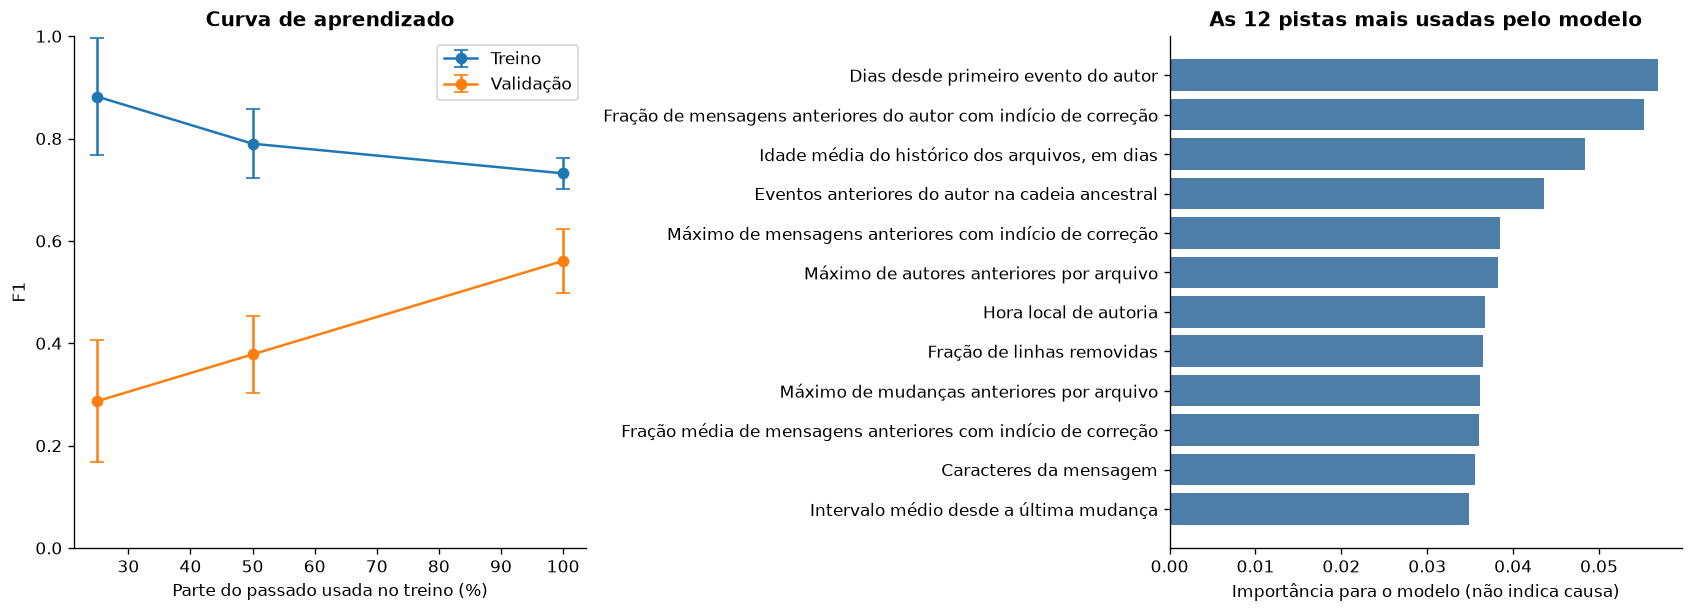

,fold,fracao,n_treino,f1_treino,f1_validacao
0,1,0.25,5041,0.9992,0.1881
1,1,0.50,10083,0.8660,0.3060
2,1,1.00,20166,0.7656,0.5132
3,2,0.25,10157,0.8742,0.2546
4,2,0.50,20314,0.7648,0.3737
5,2,1.00,40629,0.7249,0.5370
6,3,0.25,15576,0.7724,0.4183
7,3,0.50,31153,0.7390,0.4552
8,3,1.00,62307,0.7056,0.6325


**Sobreajuste ou subajuste?**

- **Sobreajuste (overfitting)** é decorar o treino. O Random Forest inicial é o exemplo claro: 1,000 no treino e 0,554 na validação.
- **O modelo escolhido ainda tem um pouco disso:** gap de 0,171 entre treino e validação. É bem menor que o do Random Forest, mas não é zero.
- **Subajuste (underfitting)** é não ter informação ou capacidade para ir bem nem no treino. Não é o caso principal aqui. Mesmo assim, o F1 de validação em torno de 0,56 mostra que as 48 pistas ainda não bastam para separar bem os commits, e parte disso vem de marcas de bug imperfeitas.

**Curva de aprendizado (gráfico da esquerda).** Em cada simulado, treinamos com 25%, 50% e 100% do passado disponível.
Com pouco passado, o modelo decora (F1 de treino 0,882) e vai mal no futuro (0,287).
Com todo o passado, o treino cai para 0,732 e a validação sobe para 0,561: a distância diminui.
Um cuidado: ao aumentar o trecho entram mais dados e também dados mais recentes, então a curva não separa os dois efeitos.

**Importância das variáveis (gráfico da direita).** As cinco pistas mais usadas pelo modelo foram:
dias desde primeiro evento do autor; fração de mensagens anteriores do autor com indício de correção; idade média do histórico dos arquivos, em dias; eventos anteriores do autor na cadeia ancestral; máximo de mensagens anteriores com indício de correção.
Pistas de autor e de histórico dos arquivos aparecem no topo, o que combina com o ganho visto no Exercício 5.
A importância mostra o que o modelo usou, não o que causa bugs. No LightGBM ela conta quantas vezes a pista foi usada nas árvores.

In [15]:
display(graficos.diagnosticos()); plt.close('all')
curva = pd.read_csv(ROOT/'resultados/curva_aprendizado.csv')
display(curva.round(4))
media = curva.groupby('fracao')[['f1_treino', 'f1_validacao']].mean()
rf = tabela[(tabela.modelo == 'Random Forest') & (tabela.estrategia == 'Baseline')].iloc[0]
importancia = pd.read_csv(ROOT/'resultados/importancia.csv').nlargest(5, 'importancia')
texto(f'''**Sobreajuste ou subajuste?**

- **Sobreajuste (overfitting)** é decorar o treino. O Random Forest inicial é o exemplo claro: {br(rf.f1_treino)} no treino e {br(rf.f1_validacao)} na validação.
- **O modelo escolhido ainda tem um pouco disso:** gap de {br(config['gap'])} entre treino e validação. É bem menor que o do Random Forest, mas não é zero.
- **Subajuste (underfitting)** é não ter informação ou capacidade para ir bem nem no treino. Não é o caso principal aqui. Mesmo assim, o F1 de validação em torno de {br(config['f1_validacao'], 2)} mostra que as 48 pistas ainda não bastam para separar bem os commits, e parte disso vem de marcas de bug imperfeitas.

**Curva de aprendizado (gráfico da esquerda).** Em cada simulado, treinamos com 25%, 50% e 100% do passado disponível.
Com pouco passado, o modelo decora (F1 de treino {br(media.loc[0.25, 'f1_treino'])}) e vai mal no futuro ({br(media.loc[0.25, 'f1_validacao'])}).
Com todo o passado, o treino cai para {br(media.loc[1.0, 'f1_treino'])} e a validação sobe para {br(media.loc[1.0, 'f1_validacao'])}: a distância diminui.
Um cuidado: ao aumentar o trecho entram mais dados e também dados mais recentes, então a curva não separa os dois efeitos.

**Importância das variáveis (gráfico da direita).** As cinco pistas mais usadas pelo modelo foram:
{'; '.join(DESCRICOES[v].lower() for v in importancia.variavel)}.
Pistas de autor e de histórico dos arquivos aparecem no topo, o que combina com o ganho visto no Exercício 5.
A importância mostra o que o modelo usou, não o que causa bugs. No LightGBM ela conta quantas vezes a pista foi usada nas árvores.''')

### 6.3 — Desbalanceamento de classes e limiar de alerta

Há mais commits sem marca de bug do que com marca de bug. Para avaliar o efeito dessa diferença,
testamos duas decisões no LightGBM selecionado:

- **Pesos de classe:** pesos iguais ou `class_weight="balanced"`. No segundo caso, o peso de cada
  exemplo é `n_amostras / (2 × n_amostras_da_classe)`, calculado somente nas linhas usadas em cada ajuste.
- **Limiar:** manter 0,50 ou escolher um valor de 0,10 a 0,90, em passos de 0,01, pelo F1 de uma
  validação interna temporal. Em empate, usamos o valor mais próximo de 0,50; depois, o maior.

Para cada fold externo, o modelo auxiliar aprende nos primeiros 80% das datas de seu treino e escolhe
o limiar nos 20% seguintes. Depois, o estimador é treinado no treino externo inteiro e avaliado no
período futuro do fold. Assim, o ajuste do limiar não usa os rótulos dessa validação externa.
As três divisões externas continuam iguais às usadas para comparar os algoritmos.

A combinação final é a de maior F1 médio externo, seguida do menor desvio; empates exatos favorecem
limiar fixo e ausência de pesos. O limiar final é calculado por outra divisão temporal interna do treino
completo. Ele pode ser diferente dos limiares obtidos nos folds.

Os hiperparâmetros do LightGBM já foram escolhidos usando esses mesmos folds. Logo, esta comparação
controla o uso dos dados no ajuste do limiar, mas não oferece uma estimativa independente de todo o
processo de seleção. Pesos de classe também não corrigem rótulos errados nem garantem melhor precision.

**Implementação do ajuste temporal compartilhada com o experimento:**

```python
def dividir_limiar(treino):
    """Últimos 20% das datas únicas; nunca divide commits com a mesma data."""
    datas = np.sort(treino.committer_date_git.unique())
    if len(datas) < 5:
        raise ValueError("Poucas datas para validação temporal do limiar.")
    corte = datas[int(len(datas) * 0.8)]
    ajuste = treino[treino.committer_date_git < corte]
    validacao = treino[treino.committer_date_git >= corte]
    if ajuste.buggy.nunique() != 2 or validacao.buggy.nunique() != 2:
        raise ValueError("Cada trecho interno precisa conter ambas as classes.")
    return ajuste, validacao
```

```python
def escolher_limiar(y, scores):
    curva = pd.DataFrame({"limiar": LIMIARES,
                          "f1": [f1_score(y, np.asarray(scores) >= t, zero_division=0) for t in LIMIARES]})
    curva["distancia_05"] = (curva.limiar - 0.5).abs().round(8)
    melhor = curva.sort_values(["f1", "distancia_05", "limiar"],
                              ascending=[False, True, False], kind="stable").iloc[0]
    return float(melhor.limiar), curva.drop(columns="distancia_05")
```

```python
def ajustar(treino, parametros, pesos, ajustar_limiar):
    params = {**parametros, "class_weight": pesos}
    limiar, curva, auditoria = LIMIAR, pd.DataFrame(), {}
    if ajustar_limiar:
        anterior, interno = dividir_limiar(treino)
        auxiliar = construir("LightGBM", params)
        auxiliar.fit(anterior[FEATURES], anterior.buggy)
        limiar, curva = escolher_limiar(interno.buggy, auxiliar.predict_proba(interno[FEATURES])[:, 1])
        auditoria = {"n_ajuste_interno": len(anterior), "n_validacao_interna": len(interno),
                     "fim_ajuste_interno": str(anterior.data.max()),
                     "inicio_validacao_interna": str(interno.data.min()),
                     "fim_validacao_interna": str(interno.data.max())}
    pipeline = construir("LightGBM", params)
    pipeline.fit(treino[FEATURES], treino.buggy)
    pipeline.limiar_decisao_ = limiar
    contagens = treino.buggy.value_counts().sort_index()
    auditoria["contagens_fit"] = contagens.to_dict()
    auditoria["pesos_fit"] = {int(c): float(len(treino)/(2*n)) if pesos else 1.0
                              for c, n in contagens.items()}
    return pipeline, curva, auditoria
```

,configuracao,f1_validacao,desvio_f1,precision,recall,acuracia_balanceada,average_precision
0,"Pesos iguais · limiar 0,50",0.5609,0.0515,0.6550,0.5123,0.6950,0.6330
1,Pesos iguais · limiar ajustado,0.6061,0.0145,0.5463,0.7073,0.7229,0.6330
2,"Pesos balanceados · limiar 0,50",0.6006,0.0215,0.5647,0.6647,0.7184,0.6265
3,Pesos balanceados · limiar ajustado,0.5935,0.0177,0.5420,0.6994,0.7152,0.6265


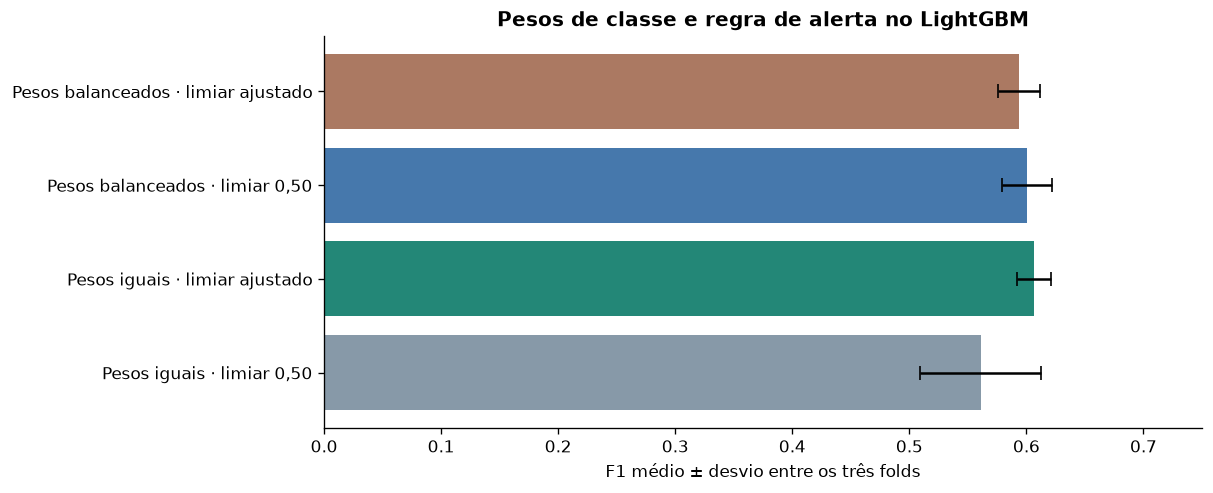

,fold,limiar,f1,precision,recall
3,1,0.29,0.6051,0.6363,0.5769
4,2,0.26,0.5888,0.5067,0.7028
5,3,0.27,0.6244,0.4961,0.8421


**Escolha da regra de alerta.** Pesos iguais · limiar ajustado:
F1 médio 0,6061, com desvio 0,0145.
A referência de pesos iguais e limiar 0,50 obteve 0,5609;
pesos balanceados com o mesmo limiar obtiveram 0,6006.
Assim, os pesos ajudaram nessa comparação, mas a maior média veio do ajuste do limiar sem pesos adicionais.
As diferenças devem ser interpretadas junto da variação entre os folds, não como superioridade definitiva.

**Resultado desta etapa:** LightGBM ajustado com Optuna, sem pesos adicionais,
limiar **0,48**. Esta é a referência para a busca ampliada da próxima seção.
O F1 0,6061 acima avalia o procedimento de ajustar um limiar em cada fold;
não corresponde a aplicar o limiar final 0,48 retroativamente a todos os folds.

,Hiperparâmetros desta etapa
n_estimators,250.00000
learning_rate,0.07903
num_leaves,27.00000
min_child_samples,60.00000
class_weight,NaN


In [16]:
texto('**Implementação do ajuste temporal compartilhada com o experimento:**')
mostrar_codigo(dividir_limiar, escolher_limiar, ajustar)

politicas = pd.read_csv(resultados_decisao/'comparacao.csv')
config_final = json.loads((resultados_decisao/'selecao.json').read_text(encoding='utf-8'))
nomes_politicas = {
    'sem_pesos_fixo': 'Pesos iguais · limiar 0,50',
    'sem_pesos_ajustado': 'Pesos iguais · limiar ajustado',
    'balanced_fixo': 'Pesos balanceados · limiar 0,50',
    'balanced_ajustado': 'Pesos balanceados · limiar ajustado',
}
quadro = politicas.assign(configuracao=politicas.id.map(nomes_politicas))
display(quadro[['configuracao', 'f1_validacao', 'desvio_f1', 'precision', 'recall',
               'acuracia_balanceada', 'average_precision']].round(4))
fig, ax = plt.subplots(figsize=(10, 4), layout='constrained')
ax.barh(quadro.configuracao, quadro.f1_validacao, xerr=quadro.desvio_f1,
        capsize=4, color=['#8799a8', '#238777', '#4678ac', '#ab7962'])
ax.set(xlabel='F1 médio ± desvio entre os três folds', xlim=(0, 0.75),
       title='Pesos de classe e regra de alerta no LightGBM')
display(graficos.salvar(fig, '05_pesos_limiar')); plt.close(fig)

folds_decisao = pd.read_json(resultados_decisao/'folds.json')
display(folds_decisao.loc[folds_decisao.id.eq(config_final['id']),
                         ['fold', 'limiar', 'f1', 'precision', 'recall']].round(4))
referencia_cv = politicas.set_index('id').loc['sem_pesos_fixo']
balanceado_cv = politicas.set_index('id').loc['balanced_fixo']
texto(f'''**Escolha da regra de alerta.** {nomes_politicas[config_final['id']]}:
F1 médio {br(config_final['f1_validacao'], 4)}, com desvio {br(config_final['desvio_f1'], 4)}.
A referência de pesos iguais e limiar 0,50 obteve {br(referencia_cv.f1_validacao, 4)};
pesos balanceados com o mesmo limiar obtiveram {br(balanceado_cv.f1_validacao, 4)}.
Assim, os pesos ajudaram nessa comparação, mas a maior média veio do ajuste do limiar sem pesos adicionais.
As diferenças devem ser interpretadas junto da variação entre os folds, não como superioridade definitiva.

**Resultado desta etapa:** LightGBM ajustado com Optuna, sem pesos adicionais,
limiar **{br(config_final['limiar'], 2)}**. Esta é a referência para a busca ampliada da próxima seção.
O F1 {br(config_final['f1_validacao'], 4)} acima avalia o procedimento de ajustar um limiar em cada fold;
não corresponde a aplicar o limiar final {br(config_final['limiar'], 2)} retroativamente a todos os folds.''')
display(pd.Series(config_final['parametros']).to_frame('Hiperparâmetros desta etapa'))

### 6.4 — Novas características e uma busca mais ampla

O tamanho total não informa **como a alteração se distribui**: 100 linhas em um único arquivo podem
ter um contexto diferente de 100 linhas divididas entre dez arquivos. Também testamos razões que
relacionam o tamanho da mudança com a experiência anterior do autor e o histórico dos arquivos.

| Conjunto | O que acrescenta | Características no modelo |
|---|---|---|
| Originais | As informações já apresentadas | 48 |
| Razões | 16 relações, como linhas por arquivo e mudança por experiência do autor | 64 |
| Dispersão | As razões mais oito medidas do diff: entropia, concentração, pastas e remoções em testes | 72 |

**Entropia:** calculamos a proporção das linhas alteradas em cada arquivo e somamos `−p × log2(p)`.
Ela é zero quando todas as linhas estão em um arquivo e cresce quando estão mais distribuídas.
Essas medidas usam apenas o diff do commit contra seu pai. Não usam rótulo, identidade do autor,
nome do projeto nem mensagens de correções futuras. Todas as métricas estáticas já existentes foram
conferidas novamente nos 105.839 commits elegíveis; nenhuma linha foi retirada nesta comparação.

**Primeiro, isolamos as características.** Comparamos os três conjuntos mantendo os mesmos parâmetros.
Repetimos essa comparação com uma configuração mais regularizada, sugerida por um piloto de oito alternativas.
No piloto, também reduzir o treino às janelas mais recentes trouxe ganho pequeno ou perda; preservamos o treino inteiro.
Esse piloto usou somente validação e está registrado em `resultados/exploracao_regularizacao/`.

,Parâmetros,pistas,n_pistas,f1_validacao,precision,recall,average_precision
34,Configuração anterior,originais,48,0.6061,0.5463,0.7073,0.6330
28,Configuração anterior,razoes,64,0.6084,0.5313,0.7385,0.6302
9,Configuração anterior,dispersao,72,0.6142,0.5422,0.7253,0.6525
17,Regularização mais forte,originais,48,0.6124,0.5214,0.7537,0.6306
29,Regularização mais forte,razoes,64,0.6077,0.5378,0.7274,0.6324
2,Regularização mais forte,dispersao,72,0.6159,0.5266,0.7558,0.6536


**Efeito das pistas com os mesmos parâmetros:** o F1 vai de 0,6061
para 0,6142, e Average Precision de 0,6330
para 0,6525. A segunda métrica avalia a ordenação dos scores,
sem depender de um único limiar. O efeito das razões isoladas aparece na linha intermediária.
Isso é evidência exploratória nesses folds, não uma garantia para o próximo período.

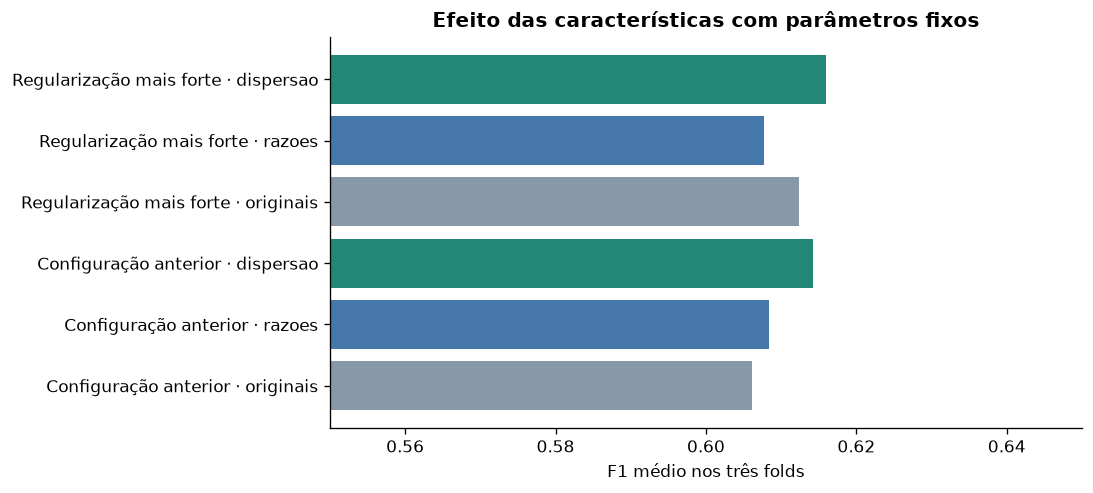

**Cálculo das pistas do diff** (`novas_pistas.py`):

```python
def dispersao_commit(commit):
    """Somente o diff do alvo contra seu pai; nenhuma informação posterior."""
    arquivos = commit['arquivos']
    if (not arquivos or len(commit['pais']) > 1 or commit['submodulo']
            or any(a[4] for a in arquivos)):
        raise ExtracaoIncompativel('Dispersão exige commit simples, textual e sem submódulos.')
    churn = np.array([a[2] + a[3] for a in arquivos], dtype=float)
    total, nf = churn.sum(), len(arquivos)
    proporcoes = churn[churn > 0] / total if total else np.array([])
    entropia = float(-(proporcoes * np.log2(proporcoes)).sum())
    removidas = sum(a[3] for a in arquivos)
    return {
        'n_entropia': entropia,
        'n_entropia_normalizada': entropia / np.log2(nf) if nf > 1 else 0.0,
        'n_fracao_churn_max': float(churn.max() / total) if total else 0.0,
        'n_coef_variacao_churn': float(churn.std() / churn.mean()) if total else 0.0,
        'n_subsistemas': len({a[1].split('/')[0] if '/' in a[1] else '' for a in arquivos}),
        'n_profundidade_media': float(np.mean([a[1].count('/') for a in arquivos])),
        'n_fracao_ld_teste': sum(a[3] for a in arquivos if eh_teste(a[1])) / removidas if removidas else 0.0,
        'n_ld_max_arquivo': max(a[3] for a in arquivos),
    }
```

In [17]:
resultados_decisao = ROOT/'resultados/melhorias'
busca_ampla = pd.read_csv(resultados_decisao/'comparacao.csv')
controles = busca_ampla[busca_ampla.tipo.eq('controle')].copy()
controles['Parâmetros'] = controles.id.str.split('_').str[0].map(
    {'anterior': 'Configuração anterior', 'regularizado': 'Regularização mais forte'})
display(controles[['Parâmetros', 'pistas', 'n_pistas', 'f1_validacao', 'precision', 'recall', 'average_precision']]
        .sort_values(['Parâmetros', 'n_pistas']).round(4))
referencia_pistas = controles.set_index('id').loc['anterior_originais']
dispersao_pistas = controles.set_index('id').loc['anterior_dispersao']
texto(f'''**Efeito das pistas com os mesmos parâmetros:** o F1 vai de {br(referencia_pistas.f1_validacao, 4)}
para {br(dispersao_pistas.f1_validacao, 4)}, e Average Precision de {br(referencia_pistas.average_precision, 4)}
para {br(dispersao_pistas.average_precision, 4)}. A segunda métrica avalia a ordenação dos scores,
sem depender de um único limiar. O efeito das razões isoladas aparece na linha intermediária.
Isso é evidência exploratória nesses folds, não uma garantia para o próximo período.''')

fig, ax = plt.subplots(figsize=(9, 4), layout='constrained')
cores = {'originais': '#8799a8', 'razoes': '#4678ac', 'dispersao': '#238777'}
plot = controles.sort_values(['Parâmetros', 'n_pistas'])
ax.barh(plot['Parâmetros'] + ' · ' + plot.pistas, plot.f1_validacao, color=plot.pistas.map(cores))
ax.set(xlabel='F1 médio nos três folds', xlim=(0.55, 0.65), title='Efeito das características com parâmetros fixos')
display(graficos.salvar(fig, '08_novas_pistas')); plt.close(fig)
texto('**Cálculo das pistas do diff** (`novas_pistas.py`):')
mostrar_codigo(dispersao_commit)

**Depois, ampliamos a busca.** Além das seis comparações controladas, executamos 24 tentativas de
LightGBM e 12 de XGBoost com Optuna. Variamos 200–800 árvores, taxa de aprendizado de 0,02–0,15,
tamanho das árvores, mínimo da folha, amostragem de linhas/colunas e regularização L1/L2.
Cada tentativa também escolhe entre os três conjuntos de pistas e pesos iguais ou balanceados.
O espaço anterior de LightGBM só chegava a 60 amostras por folha; agora vai de 50 a 500.

O limiar segue a mesma validação temporal interna da seção anterior. No caso balanceado, ambos
os algoritmos recebem pesos por amostra calculados só no trecho de cada ajuste; a proporção de
classes na validação não muda. As razões são calculadas por uma etapa compartilhada do pipeline.

**Escolha desta busca, definida antes de executá-la:** maior F1 médio dos três folds; empates por
menor desvio, menos características e menos árvores. As seis comparações controladas também são
candidatas: a busca não obriga escolher uma configuração nova. Reutilizar os folds aumenta o risco
de adaptação à validação. O protocolo e todas as 42 configurações estão em `PROTOCOLO_MELHORIAS.md`
e `resultados/melhorias/`; mostramos abaixo as oito primeiras, sem esconder as demais no registro.

In [18]:
for algoritmo, esperado in [('lightgbm', 24), ('xgboost', 12)]:
    trials = pd.read_csv(resultados_decisao/f'trials_{algoritmo}.csv')
    assert trials.state.eq('COMPLETE').sum() == esperado
assert len(busca_ampla) == 42
display(busca_ampla[['id', 'modelo', 'pistas', 'pesos', 'f1_validacao', 'desvio_f1',
                    'precision', 'recall', 'average_precision']].head(8).round(4))
config_final = json.loads((resultados_decisao/'selecao.json').read_text(encoding='utf-8'))
escolha = json.loads((resultados_decisao/'selecao_validacao.json').read_text(encoding='utf-8'))
assert not escolha['holdout_usado_na_selecao']
assert config_final['id'] == busca_ampla.iloc[0]['id']
display(pd.DataFrame(escolha['folds'])[['fold', 'limiar', 'f1', 'precision', 'recall', 'average_precision']].round(4))
texto(f'''**Modelo selecionado:** {config_final['modelo']}, conjunto **{config_final['pistas']}**,
pesos **{config_final['pesos'] or 'iguais'}**. F1 médio **{br(config_final['f1_validacao'], 4)}**
(referência anterior: {br(referencia_pistas.f1_validacao, 4)}), desvio {br(config_final['desvio_f1'], 4)}.
O limiar para o modelo treinado com todo o passado é **{br(config_final['limiar'], 2)}**,
definido só no treino. A validação acima usa o limiar próprio de cada fold, não esse valor final retroativamente.
A configuração e o limiar foram gravados antes de consultar a avaliação final.''')
display(pd.Series(config_final['parametros']).to_frame('Hiperparâmetros finais'))
treino_enriquecido = carregar_pistas(treino)
texto('**Procedimento de ajuste e limiar usado em cada rodada:**')
mostrar_codigo(ajustar_ampliado)

,id,modelo,pistas,pesos,f1_validacao,desvio_f1,precision,recall,average_precision
0,lightgbm_06,LightGBM,razoes,balanced,0.6168,0.0194,0.5379,0.7382,0.6357
1,lightgbm_15,LightGBM,razoes,balanced,0.6160,0.0119,0.5468,0.7241,0.6345
2,regularizado_dispersao,LightGBM,dispersao,NaN,0.6159,0.0115,0.5266,0.7558,0.6536
3,lightgbm_10,LightGBM,razoes,balanced,0.6154,0.0171,0.5430,0.7273,0.6356
4,lightgbm_07,LightGBM,dispersao,NaN,0.6154,0.0199,0.5168,0.7645,0.6471
5,lightgbm_13,LightGBM,razoes,balanced,0.6151,0.0133,0.5492,0.7116,0.6339
6,lightgbm_11,LightGBM,razoes,balanced,0.6148,0.0154,0.5253,0.7555,0.6367
7,lightgbm_21,LightGBM,razoes,balanced,0.6147,0.0124,0.5404,0.7284,0.6342


,fold,limiar,f1,precision,recall,average_precision
0,1,0.49,0.6182,0.6017,0.6357,0.6562
1,2,0.36,0.5923,0.4728,0.7927,0.5943
2,3,0.55,0.6398,0.5393,0.7861,0.6565


**Modelo selecionado:** LightGBM, conjunto **razoes**,
pesos **balanced**. F1 médio **0,6168**
(referência anterior: 0,6061), desvio 0,0194.
O limiar para o modelo treinado com todo o passado é **0,71**,
definido só no treino. A validação acima usa o limiar próprio de cada fold, não esse valor final retroativamente.
A configuração e o limiar foram gravados antes de consultar a avaliação final.

,Hiperparâmetros finais
n_estimators,400.000000
learning_rate,0.055726
reg_alpha,4.268408
reg_lambda,0.559599
subsample,0.793634
colsample_bytree,0.914443
num_leaves,31.000000
min_child_samples,500.000000
min_split_gain,0.404060
subsample_freq,1.000000


**Procedimento de ajuste e limiar usado em cada rodada:**

```python
def ajustar_ampliado(treino, config):
    """O limiar vê só o trecho interno; pesos são calculados por fit."""
    colunas = colunas_entrada(config['pistas'])
    anterior, interno = dividir_limiar(treino)
    contagens, pesos = [], []
    def fit(frame):
        pipe = construir_ampliado(config)
        kwargs = {}
        contagens.append({str(k): int(v) for k, v in frame.buggy.value_counts().sort_index().items()})
        if config['pesos'] == 'balanced':
            w = compute_sample_weight('balanced', frame.buggy)
            kwargs['modelo__sample_weight'] = w
            pesos.append({str(c): float(w[frame.buggy.to_numpy() == c][0]) for c in (0, 1)})
        else:
            pesos.append({'0': 1.0, '1': 1.0})
        pipe.fit(frame[colunas], frame.buggy, **kwargs)
        return pipe
    auxiliar = fit(anterior)
    limiar, curva = escolher_limiar(interno.buggy, auxiliar.predict_proba(interno[colunas])[:, 1])
    pipe = fit(treino)
    pipe.limiar_decisao_ = limiar
    pipe.variante_pistas_ = config['pistas']
    auditoria = {
        'n_ajuste_interno': len(anterior), 'n_validacao_interna': len(interno), 'n_treino': len(treino),
        'fim_ajuste_interno': str(anterior.data.max()), 'inicio_validacao_interna': str(interno.data.min()),
        'fim_treino': str(treino.data.max()), 'contagens_por_fit': contagens, 'pesos_por_fit': pesos,
    }
    return pipe, curva, auditoria
```

#### Quais características mais pesaram no modelo final?

Agora examinamos o **LightGBM final, com 64 características e 400 árvores**, já treinado e salvo.
A importância por **ganho** soma quanto as divisões que usaram cada característica melhoraram
o objetivo do modelo durante o treinamento. Dividimos cada soma pelo ganho total das 64 entradas.
Assim, 27,2% para linhas adicionadas significa 27,2% desse ganho acumulado — **não** uma
probabilidade de bug nem o efeito de adicionar uma linha.

O gráfico resume as cinco primeiras; a tabela mostra as dez primeiras. O ranking completo
fica em [importancia_final.csv](resultados/melhorias/importancia_final.csv), com os nomes
das 64 características, seus significados, ganhos e quantidades de divisões.

Na seção 6.2, o gráfico do modelo inicial usa a **quantidade de divisões** (*split*).
Aqui usamos **ganho** (*gain*) no modelo final: são critérios diferentes, portanto os rankings
não são diretamente comparáveis. Características relacionadas, como adições e total de linhas
alteradas, podem compartilhar importância. Essa leitura é descritiva do treinamento; não mede
causalidade, direção do efeito ou a melhora do F1 que uma variável produziria isoladamente.
O cálculo abaixo apenas lê o modelo salvo: não o treina de novo nem muda seu limiar.

Fonte do método: [LightGBM — feature_importance](https://lightgbm.readthedocs.io/en/stable/pythonapi/lightgbm.Booster.html#lightgbm.Booster.feature_importance).

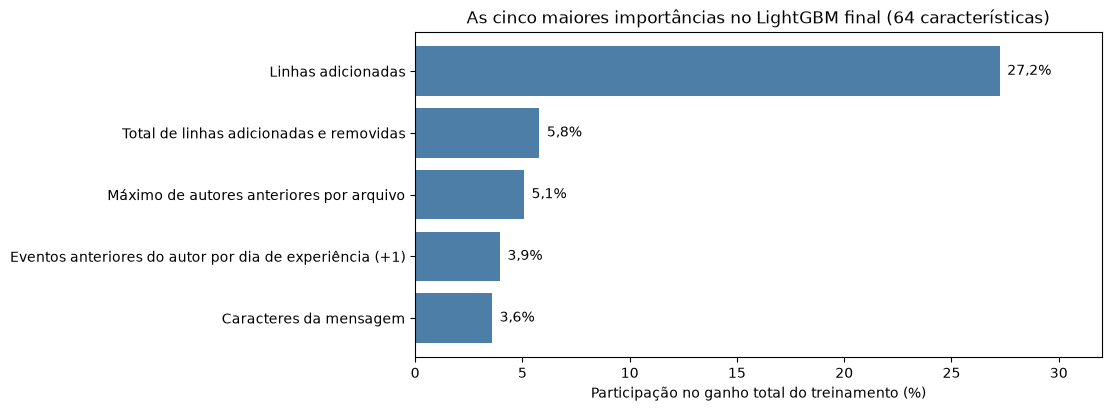

,variavel,significado,Ganho (%),Divisões
0,la,Linhas adicionadas,27.25,196
1,d_churn,Total de linhas adicionadas e removidas,5.79,111
2,l_arq_autores_max,Máximo de autores anteriores por arquivo,5.07,428
3,d_atividade_autor_por_dia,Eventos anteriores do autor por dia de experiência (+1),3.95,521
4,m_caracteres,Caracteres da mensagem,3.58,404
5,w_autor_frac_correcoes,Fração de mensagens anteriores do autor com indício de correção,3.18,602
6,l_arq_dias_desde_ultima_media,Intervalo médio desde a última mudança,2.78,300
7,m_linhas,Linhas da mensagem,2.54,170
8,l_arq_idade_media_d,"Idade média do histórico dos arquivos, em dias",2.50,505
9,l_arq_mudancas_max,Máximo de mudanças anteriores por arquivo,2.33,356


Ranking completo: 64 características; 400 árvores; arquivo resultados/melhorias/importancia_final.csv


In [ ]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
from esquema import ROOT, DESCRICOES
from novas_pistas import DERIVADAS
from modelo import carregar_modelo

# O carregamento confere os hashes do modelo e do esquema usados no treinamento.
pipeline_final, metadados_final = carregar_modelo(pasta=ROOT/'artefatos/melhorias')
arvores_final = pipeline_final.named_steps['modelo'].booster_
nomes_final = arvores_final.feature_name()
assert nomes_final == metadados_final['variaveis_modelo'] and len(nomes_final) == 64
ganhos_final = arvores_final.feature_importance(importance_type='gain', iteration=-1)
divisoes_final = arvores_final.feature_importance(importance_type='split', iteration=-1)
assert np.isfinite(ganhos_final).all() and (ganhos_final >= 0).all() and ganhos_final.sum() > 0
descricoes_final = {**DESCRICOES, **DERIVADAS}
importancia_final = pd.DataFrame({
    'variavel': nomes_final,
    'significado': [descricoes_final[nome] for nome in nomes_final],
    'ganho': ganhos_final,
    'ganho_pct': 100 * ganhos_final / ganhos_final.sum(),
    'divisoes': divisoes_final,
}).sort_values('ganho', ascending=False, kind='stable').reset_index(drop=True)
assert np.isclose(importancia_final.ganho_pct.sum(), 100)

pasta_importancia = ROOT/'resultados/melhorias'
importancia_final.to_csv(pasta_importancia/'importancia_final.csv', index=False)
registro_importancia = {
    'modelo': metadados_final['modelo'],
    'pipeline_sha256': metadados_final['pipeline_sha256'],
    'caracteristicas': len(nomes_final),
    'arvores': arvores_final.num_trees(),
    'metrica': 'gain: soma dos ganhos das divisões, normalizada pelas 64 características',
    'fonte': 'artefatos/melhorias/pipeline.joblib',
    'ranking': importancia_final.to_dict(orient='records'),
}
(pasta_importancia/'importancia_final.json').write_text(
    json.dumps(registro_importancia, ensure_ascii=False, indent=2) + '\n', encoding='utf-8')

top_final = importancia_final.head(5).iloc[::-1]
fig, ax = plt.subplots(figsize=(11, 4), layout='constrained')
ax.barh(top_final.significado, top_final.ganho_pct, color='#4d7ea8')
ax.set(title='As cinco maiores importâncias no LightGBM final (64 características)',
       xlabel='Participação no ganho total do treinamento (%)', xlim=(0, 32))
for linha, valor in enumerate(top_final.ganho_pct):
    ax.text(valor + 0.35, linha, f'{valor:.1f}%'.replace('.', ','), va='center')
fig.savefig(ROOT/'figuras/09_importancia_modelo_final.png', dpi=160, bbox_inches='tight')
display(fig)
plt.close(fig)
display(importancia_final.head(10)[['variavel', 'significado', 'ganho_pct', 'divisoes']]
        .rename(columns={'ganho_pct': 'Ganho (%)', 'divisoes': 'Divisões'})
        .style.format({'Ganho (%)': '{:.2f}'}))
print(f'Ranking completo: {len(importancia_final)} características; '
      f'{arvores_final.num_trees()} árvores; arquivo resultados/melhorias/importancia_final.csv')

### 6.5 — Desempenho da regra selecionada na validação

Reunimos abaixo as previsões dos três folds externos. Cada commit foi avaliado por um modelo treinado
com commits de datas anteriores e rótulos retrospectivos, usando o limiar escolhido naquele fold. A média dos F1 dos folds e o F1 das
previsões reunidas são medidas diferentes; a seleção usa a primeira.
A curva precision–recall mostra a qualidade da ordenação pelos scores, independentemente de um único limiar.

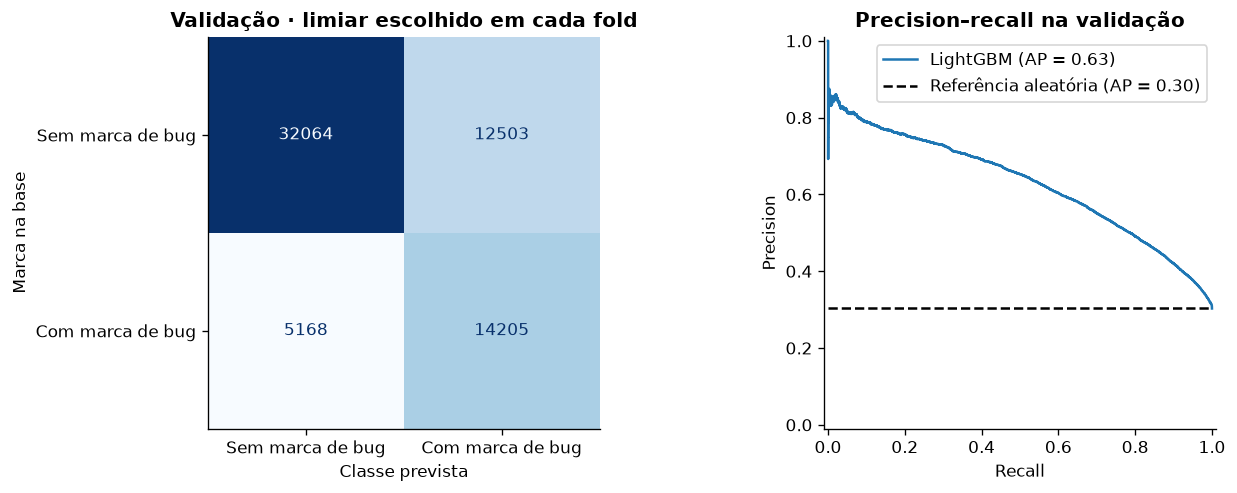

,Previsões externas reunidas
F1 agregado,0.6165
Precision,0.5319
Recall,0.7332


Foram avaliados **63.940 commits** na validação externa.
A regra alertou 26.708: 14.205 tinham marca de bug e 12.503 eram falsos alarmes.
Ficaram sem alerta 5.168 commits marcados como buggy.
O primeiro trecho do treino não tem previsão externa porque foi usado apenas para aprender.

,project_familia,commits,taxa_buggy,precision,recall,f1,verdadeiros_negativos,falsos_positivos,falsos_negativos,verdadeiros_positivos
5,apache/hadoop (familia),10169,0.2531,0.3314,0.7335,0.4565,3786,3809,686,1888
1,apache/camel,11938,0.1399,0.3159,0.5353,0.3973,8332,1936,776,894
8,apache/ignite,10440,0.1736,0.4561,0.6137,0.5233,7302,1326,700,1112
3,apache/flink,6674,0.2734,0.5470,0.8197,0.6561,3610,1239,329,1496
6,apache/hbase,5323,0.5035,0.6779,0.8112,0.7386,1610,1033,506,2174
2,apache/cassandra,5594,0.3801,0.6058,0.6787,0.6402,2529,939,683,1443


**Diferenças entre famílias.** Hadoop, HDFS e MapReduce foram reunidos conforme a auditoria do Exercício 2. A correção muda a interpretação por grupo, sem mudar o F1 global nem excluir erros. O desempenho continua desigual, e as marcas negativas não certificam ausência de defeito. A lista com os nomes originais também foi preservada em resultados/melhorias/erros_por_projeto.csv.

In [19]:
oof = pd.read_parquet(resultados_decisao/'previsoes_validacao.parquet')
assert oof.commit_id.is_unique
fig, ax = plt.subplots(1, 2, figsize=(11, 4), layout='constrained')
ConfusionMatrixDisplay.from_predictions(oof.buggy, oof.previsao, labels=[0, 1],
    display_labels=['Sem marca de bug', 'Com marca de bug'], ax=ax[0], colorbar=False, cmap='Blues')
ax[0].set(title='Validação · limiar escolhido em cada fold', xlabel='Classe prevista', ylabel='Marca na base')
PrecisionRecallDisplay.from_predictions(oof.buggy, oof.score, ax=ax[1], name=config_final['modelo'], plot_chance_level=True)
objetos, legendas = ax[1].get_legend_handles_labels()
ax[1].legend(objetos, [s.replace('Chance level', 'Referência aleatória') for s in legendas])
ax[1].set(title='Precision–recall na validação', xlabel='Recall', ylabel='Precision')
display(graficos.salvar(fig, '06_validacao_decisao')); plt.close(fig)

v = {'F1 agregado': f1_score(oof.buggy, oof.previsao),
     'Precision': precision_score(oof.buggy, oof.previsao),
     'Recall': recall_score(oof.buggy, oof.previsao)}
display(pd.Series(v).round(4).to_frame('Previsões externas reunidas'))
(tn, fp), (fn, tp) = confusion_matrix(oof.buggy, oof.previsao, labels=[0, 1])
texto(f'''Foram avaliados **{mil(len(oof))} commits** na validação externa.
A regra alertou {mil(tp + fp)}: {mil(tp)} tinham marca de bug e {mil(fp)} eram falsos alarmes.
Ficaram sem alerta {mil(fn)} commits marcados como buggy.
O primeiro trecho do treino não tem previsão externa porque foi usado apenas para aprender.''')
por_familia = pd.read_csv(PASTA_AUDITORIA/'erros_por_familia.csv')
assert por_familia.commits.sum() == len(oof)
assert por_familia.falsos_positivos.sum() == fp
display(por_familia.sort_values('falsos_positivos', ascending=False).head(6).round(4))
texto('**Diferenças entre famílias.** Hadoop, HDFS e MapReduce foram reunidos conforme a auditoria '
      'do Exercício 2. A correção muda a interpretação por grupo, sem mudar o F1 global nem excluir '
      'erros. O desempenho continua desigual, e as marcas negativas não certificam ausência de defeito. '
      'A lista com os nomes originais também foi preservada em resultados/melhorias/erros_por_projeto.csv.')

## Exercício 7 — Avaliação final, consistência e aplicação

### 7.1 — Avaliação principal: outubro de 2017 a dezembro de 2018

Com a configuração definida, repetimos seu ajuste em todo o treino, incluindo o cálculo interno do limiar,
e conferimos a igualdade com o modelo salvo que o app carrega. A tabela compara quatro regras nos
**mesmos 11.292 commits**: o modelo final, a versão anterior com limiar ajustado, o LightGBM original
com limiar 0,50 e a classe majoritária.

Esta célula reproduz uma avaliação já registrada. O período é conhecido, conforme a limitação do
Exercício 3; os números não são usados para fazer novas escolhas de modelo ou limiar.

,Modelo final,Versão anterior · limiar ajustado,"LightGBM original · limiar 0,50",Sempre sem bug
f1,0.5843,0.5851,0.5877,0.0000
precision,0.5520,0.5201,0.5351,0.0000
recall,0.6206,0.6687,0.6516,0.0000
acuracia,0.8081,0.7939,0.8013,0.7827
acuracia_balanceada,0.7404,0.7487,0.7472,0.5000
roc_auc,0.8376,0.8424,0.8424,0.5000
average_precision,0.6159,0.6210,0.6210,0.2173


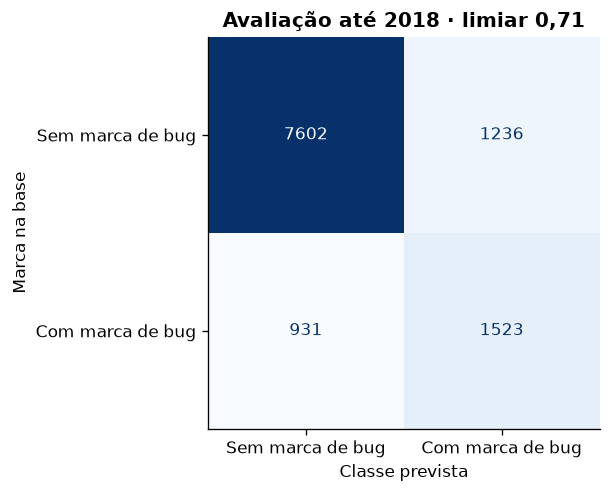

**Resultado.** O F1 passou de 0,6168 na validação média para
**0,5843** na avaliação principal. Precision foi 55,2% e recall, 62,1%.
Em 11.292 commits, o modelo encontrou 1.523 bugs, gerou 1.236 falsos alarmes e
deixou de alertar 931 commits marcados como buggy.

**Comparação justa.** A versão imediatamente anterior teve F1 0,5851.
O novo modelo não melhorou o F1 nesse período: diferença **-0,0008**.
Em relação à versão anterior, a diferença é de **-118 bugs encontrados**
e **-278 falsos alarmes**. A referência original com limiar 0,50
teve F1 0,5877. Todas essas comparações usam exatamente as mesmas linhas.

**Incerteza.** Um bootstrap pareado de 1.000 reamostragens de semanas inteiras produz intervalo
descritivo de 95% de [-0,0111; 0,0095] para a diferença de F1 em relação à versão anterior.
Esse intervalo não corrige o uso anterior do holdout nem transforma o resultado em uma confirmação independente.
Não mudamos a configuração depois de consultar esses resultados.

**Generalização.** O modelo conserva capacidade de ordenar os commits (ROC-AUC 0,8376),
mas ainda comete muitos erros. Esses resultados sustentam seu uso exploratório para priorização,
sem demonstrar desempenho em outros tipos de projeto ou em dados inéditos.

In [20]:
from revisar_balanceamento import medir as medir_decisao

pipeline, meta = carregar_modelo()
assert meta['limiar'] == config_final['limiar']
assert meta['parametros'] == config_final['parametros']
reajustado, _, _ = ajustar_ampliado(treino_enriquecido, config_final)
assert reajustado.limiar_decisao_ == config_final['limiar']
teste = carregar_pistas(teste)
pred = prever(reajustado, teste)
salvo = prever(pipeline, teste)
np.testing.assert_allclose(pred.score, salvo.score, rtol=0, atol=1e-10)
np.testing.assert_array_equal(pred.previsao, salvo.previsao)

resultado = json.loads((resultados_decisao/'teste_final.json').read_text(encoding='utf-8'))
m = medir_decisao(teste.buggy, pred.score, meta['limiar'])
for chave, valor in m.items():
    np.testing.assert_allclose(valor, resultado['metricas'][chave], rtol=0, atol=1e-12)
referencia, maioria = resultado['original_mesmos_commits'], resultado['referencia_majoritaria']
anterior = resultado['anterior_mesmos_commits']
display(pd.DataFrame({'Modelo final': m, 'Versão anterior · limiar ajustado': anterior,
                      'LightGBM original · limiar 0,50': referencia,
                      'Sempre sem bug': maioria}).round(4))

fig, ax = plt.subplots(figsize=(6, 4), layout='constrained')
ConfusionMatrixDisplay.from_predictions(teste.buggy, pred.previsao, labels=[0, 1],
    display_labels=['Sem marca de bug', 'Com marca de bug'], ax=ax, colorbar=False, cmap='Blues')
ax.set(title=f'Avaliação até 2018 · limiar {br(meta["limiar"], 2)}',
       xlabel='Classe prevista', ylabel='Marca na base')
display(graficos.salvar(fig, '07_avaliacao_principal')); plt.close(fig)
(tn, fp), (fn, tp) = resultado['matriz_confusao']
delta = m['f1'] - anterior['f1']
lo, hi = resultado['incerteza_vs_anterior']['delta_f1_ic95']
texto(f'''**Resultado.** O F1 passou de {br(config_final['f1_validacao'], 4)} na validação média para
**{br(m['f1'], 4)}** na avaliação principal. Precision foi {pct(m['precision'])} e recall, {pct(m['recall'])}.
Em {mil(len(teste))} commits, o modelo encontrou {mil(tp)} bugs, gerou {mil(fp)} falsos alarmes e
deixou de alertar {mil(fn)} commits marcados como buggy.

**Comparação justa.** A versão imediatamente anterior teve F1 {br(anterior['f1'], 4)}.
O novo modelo {'melhorou' if delta > 0 else 'não melhorou'} o F1 nesse período: diferença **{br(delta, 4)}**.
Em relação à versão anterior, a diferença é de **{tp - resultado['matriz_anterior'][1][1]:+d} bugs encontrados**
e **{fp - resultado['matriz_anterior'][0][1]:+d} falsos alarmes**. A referência original com limiar 0,50
teve F1 {br(referencia['f1'], 4)}. Todas essas comparações usam exatamente as mesmas linhas.

**Incerteza.** Um bootstrap pareado de 1.000 reamostragens de semanas inteiras produz intervalo
descritivo de 95% de [{br(lo, 4)}; {br(hi, 4)}] para a diferença de F1 em relação à versão anterior.
Esse intervalo não corrige o uso anterior do holdout nem transforma o resultado em uma confirmação independente.
Não mudamos a configuração depois de consultar esses resultados.

**Generalização.** O modelo conserva capacidade de ordenar os commits (ROC-AUC {br(m['roc_auc'], 4)}),
mas ainda comete muitos erros. Esses resultados sustentam seu uso exploratório para priorização,
sem demonstrar desempenho em outros tipos de projeto ou em dados inéditos.''')

### 7.2 — Sensibilidade ao período de 2019

Esta análise complementar verifica como o desempenho muda em outro período. A frequência de rótulos
buggy também muda, o que afeta precision e F1. Possíveis explicações incluem diferenças entre os commits
e tempo insuficiente para identificar bugs recentes; estes dados não permitem separar essas causas.
As comparações de regras continuam sendo feitas dentro de cada período.

In [21]:
sensibilidade = json.loads((resultados_decisao/'sensibilidade_2019.json').read_text(encoding='utf-8'))
periodos = pd.DataFrame([
    {'Período': 'Out/2017–2018 · principal', 'Commits': len(teste), 'Fração buggy': teste.buggy.mean(),
     'F1 final': m['f1'], 'F1 anterior': anterior['f1'], 'Precision final': m['precision'], 'Recall final': m['recall']},
    {'Período': '2019 · complementar', 'Commits': len(teste_2019), 'Fração buggy': teste_2019.buggy.mean(),
     'F1 final': sensibilidade['metricas']['f1'], 'F1 anterior': sensibilidade['anterior_mesmos_commits']['f1'],
     'Precision final': sensibilidade['metricas']['precision'], 'Recall final': sensibilidade['metricas']['recall']},
])
display(periodos.set_index('Período').round(4))
texto(f'''Em 2019, {pct(teste_2019.buggy.mean())} dos commits têm marca de bug, contra
{pct(teste.buggy.mean())} na avaliação principal. O F1 final cai para
{br(sensibilidade['metricas']['f1'], 4)}. A diferença reforça a sensibilidade do modelo ao período
e a necessidade de avaliar novos dados. Não podemos interpretar a retirada de 2019 da métrica
principal como ganho de aprendizagem: nenhum commit desse ano participou do treino.''')

,Commits,Fração buggy,F1 final,F1 anterior,Precision final,Recall final
Período,,,,,,
Out/2017–2018 · principal,11292,0.2173,0.5843,0.5851,0.5520,0.6206
2019 · complementar,10441,0.1013,0.4150,0.4096,0.3102,0.6267


Em 2019, 10,1% dos commits têm marca de bug, contra
21,7% na avaliação principal. O F1 final cai para
0,4150. A diferença reforça a sensibilidade do modelo ao período
e a necessidade de avaliar novos dados. Não podemos interpretar a retirada de 2019 da métrica
principal como ganho de aprendizagem: nenhum commit desse ano participou do treino.

### 7.3 — Casos individuais e paridade com o aplicativo

Os seis exemplos abaixo não participaram do treino. Incluem um caso de cada tipo de acerto e erro,
o score mais próximo do limiar e um score baixo. Essa escolha serve para explicar o comportamento;
as métricas da seção anterior usam todo o período, não apenas os exemplos.

O teste recarrega os mesmos artefatos usados pela interface e compara scores e classes com os registros salvos.

In [22]:
exemplos = pd.read_csv(pasta_artefatos()/'exemplos.csv')
mesmas = prever(pipeline, exemplos)
assert len(exemplos) >= 5
assert not set(exemplos.commit_id) & set(treino.commit_id)
assert set(exemplos.commit_id) <= set(teste.commit_id)
np.testing.assert_allclose(mesmas.score, exemplos.score, rtol=0, atol=1e-12)
np.testing.assert_array_equal(mesmas.previsao, exemplos.previsao)
display(exemplos[['project', 'commit_id', 'la', 'ld', 'nf', 'l_arq_mudancas_max',
                  'w_autor_commits', 'buggy', 'score', 'previsao', 'caso']])
print(f'Paridade confirmada em {len(exemplos)} exemplos; limiar {br(meta["limiar"], 2)}.')

vp = exemplos[exemplos.caso.eq('Verdadeiro positivo')].iloc[0]
fn_ex = exemplos[exemplos.caso.eq('Falso negativo')].iloc[0]
fp_ex = exemplos[exemplos.caso.eq('Falso positivo')].iloc[0]
perto = exemplos.loc[(exemplos.score - meta['limiar']).abs().idxmin()]
claro = exemplos.loc[exemplos.score.idxmin()]
texto(f'''**Leitura dos casos**

- **Acerto positivo:** `{vp.commit_id[:8]}`, com score {br(vp.score, 4)}, foi alertado e tem marca de bug.
  Os arquivos alterados têm até {vp.l_arq_mudancas_max:.0f} mudanças anteriores, característica relevante no modelo.
- **Falso negativo:** `{fn_ex.commit_id[:8]}`, score {br(fn_ex.score, 4)}, tem marca de bug, mas ficou abaixo do limiar.
  Isso mostra por que uma classe 0 não dispensa revisão e testes.
- **Falso positivo:** `{fp_ex.commit_id[:8]}`, score {br(fp_ex.score, 4)}, foi alertado sem ter marca de bug.
  O score expressa uma associação estatística, não a confirmação de um defeito.
- **Próximo da decisão:** `{perto.commit_id[:8]}`, score {br(perto.score, 6)}, está muito perto de
  {br(meta['limiar'], 2)}. Pequenas mudanças no limiar alterariam sua classe.
- **Score baixo:** `{claro.commit_id[:8]}`, score {br(claro.score, 6)}, é um {claro.caso.lower()}.
  Um acerto individual também não é garantia de acerto em novos commits.

No app local, cada um desses exemplos exibe **“Paridade confirmada”** quando classe e score coincidem
com o registro. O teste automático dessa interface está em `testar_projeto.py`.''')

faixas = pd.read_csv(pasta_artefatos()/'faixas.csv')
display(faixas.round(4))
texto('As faixas usadas no aplicativo resumem a frequência de buggy nas previsões de validação. '
      'São uma referência descritiva de outro período; não calibram a probabilidade de cada commit.')

,project,commit_id,la,ld,nf,l_arq_mudancas_max,w_autor_commits,buggy,score,previsao,caso
0,apache/camel,b584b3d304127dcaacb6ee12972fded1ae5bdd2d,486,1,8,20,7,0,0.573157,0,Verdadeiro negativo
1,apache/flink,c3235c395f7bb69b482b85c6832d427100130ca3,461,399,26,25,103,0,0.793676,1,Falso positivo
2,apache/kafka,10cd98cc894b88c5d1e24fc54c66361ad9914df2,145,127,7,198,60,1,0.912967,1,Verdadeiro positivo
3,apache/camel,2712739524cc9c263b2013fbd19a69a6404620e1,117,332,10,2,4,1,0.284304,0,Falso negativo
4,apache/hadoop,9a7e81083801a57d6bb96584988415cbef67460d,835,29,7,123,114,0,0.710027,1,Falso positivo
5,apache/hadoop,7290324fc8b51beaff90199e98d2ce3f9854ab50,0,1,1,10,145,0,0.001499,0,Verdadeiro negativo


Paridade confirmada em 6 exemplos; limiar 0,71.


**Leitura dos casos**

- **Acerto positivo:** `10cd98cc`, com score 0,9130, foi alertado e tem marca de bug.
  Os arquivos alterados têm até 198 mudanças anteriores, característica relevante no modelo.
- **Falso negativo:** `27127395`, score 0,2843, tem marca de bug, mas ficou abaixo do limiar.
  Isso mostra por que uma classe 0 não dispensa revisão e testes.
- **Falso positivo:** `c3235c39`, score 0,7937, foi alertado sem ter marca de bug.
  O score expressa uma associação estatística, não a confirmação de um defeito.
- **Próximo da decisão:** `9a7e8108`, score 0,710027, está muito perto de
  0,71. Pequenas mudanças no limiar alterariam sua classe.
- **Score baixo:** `7290324f`, score 0,001499, é um verdadeiro negativo.
  Um acerto individual também não é garantia de acerto em novos commits.

No app local, cada um desses exemplos exibe **“Paridade confirmada”** quando classe e score coincidem
com o registro. O teste automático dessa interface está em `testar_projeto.py`.

,faixa,score_minimo,commits,taxa_buggy,taxa_geral
0,Baixo,0.0,20691,0.0815,0.303
1,Moderado,0.2,18413,0.2202,0.303
2,Alto,0.5,9187,0.3862,0.303
3,Muito alto,0.7,15649,0.6444,0.303


As faixas usadas no aplicativo resumem a frequência de buggy nas previsões de validação. São uma referência descritiva de outro período; não calibram a probabilidade de cada commit.

### 7.4 — Aplicação e reprodução

O aplicativo permite escolher um dos exemplos locais ou analisar um commit de um repositório público.
Mostra o score, a classe, o limiar, as entradas e as razões derivadas. No modo GitHub, calcula o histórico anterior ao commit
com o mesmo extrator usado no treino; históricos incompletos, merges e arquivos binários são recusados.

- **Código do projeto:** https://github.com/DaviJDuarte/DataScience-CP5
- **Endereço publicado:** https://datascience-cp5-davi.streamlit.app/
- **Execução local:** `python -m streamlit run app.py`.

O endereço publicado é implantado a partir deste repositório e usa o mesmo modelo e o mesmo limiar
deste notebook. Por isso, os resultados online coincidem com os demonstrados aqui.

Para reproduzir: instale `requirements.txt`, execute as células em ordem e mantenha as pastas de
resultados e artefatos fornecidas. `treinamento.py` reproduz a comparação inicial de algoritmos;
`buscar_melhorias.py` reproduz a busca ampliada e `finalizar_melhorias.py` verifica ou produz o modelo final.
`extrair_dispersao.py` confere o cache adicional; para extraí-lo do zero, configure `CP5_REPOS_DIR` com os clones Git.
`executar_notebook.py` executa e salva todas as saídas. Os testes estão em `testar_projeto.py`,
`testar_balanceamento.py`, `testar_extracao.py`, `testar_melhorias.py` e `testar_rotulos.py`.
`auditar_rotulos.py` reproduz a auditoria com o pacote original e os clones; as células usam seus
resultados persistidos, sem precisar baixar esses arquivos.

### Conclusão e limitações

As características de histórico de autores e arquivos acrescentaram informação em relação ao tamanho
do commit. Random Forest, XGBoost e LightGBM tiveram resultados próximos na primeira comparação.
O ajuste do limiar foi útil na validação, mas sozinho não melhorou o F1 final. Por isso investigamos
também razões, dispersão da mudança e regularização em uma busca ampliada. A escolha final foi feita
na validação e sua comparação no período posterior está quantificada na seção 7.1. Esses experimentos
não demonstram que atingimos o melhor modelo possível para o problema.

O projeto demonstra um fluxo de priorização de revisão, com preparação compartilhada entre treino e
aplicação e previsões reproduzíveis. A frequência de falsos alarmes ainda é alta. A auditoria reproduziu
os rótulos, corrigiu o agrupamento Hadoop nos diagnósticos e identificou vínculos para revisão.
Rótulos SZZ imperfeitos, disponibilidade tardia de parte das marcas, mudança temporal e uso de um
período já conhecido limitam a conclusão. Os dados representam projetos
Apache, predominantemente Java, e não estabelecem desempenho em outros contextos. O score não é uma
probabilidade calibrada. Uma confirmação de generalização requer commits novos e rótulos independentes.

### Referências

- Keshavarz, H.; Nagappan, M. *ApacheJIT: A Large Dataset for Just-In-Time Defect Prediction*. [Dados e DOI](https://zenodo.org/records/5907847); [artigo](https://arxiv.org/abs/2203.00101).
- Breiman (2001), *Random Forests*; Chen e Guestrin (2016), *XGBoost*; Ke et al. (2017), *LightGBM*; Akiba et al. (2019), *Optuna*.
- [LightGBM: pesos de classe](https://lightgbm.readthedocs.io/en/latest/pythonapi/lightgbm.LGBMClassifier.html).
- [LightGBM: regularização e ajuste](https://lightgbm.readthedocs.io/en/stable/Parameters-Tuning.html).
- [XGBoost: parâmetros](https://xgboost.readthedocs.io/en/stable/parameter.html).
- [scikit-learn: escolha do limiar de decisão](https://scikit-learn.org/stable/modules/classification_threshold.html).
- Enunciado do Checkpoint 5 e notebooks das aulas 18, 19 e 20 da disciplina.